# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 26 - 4to bimestre 2026

## **Alumno 1:** Rodrigo Hernández

Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23:59 hs del domingo 20 de septiembre (hora de Argentina)**.

La resolución del TP puede realizarse de forma **individual, en parejas o hasta en grupos de 3 como máximo**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que todos los integrantes deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP1 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local (posteriormente deben subirlo a Google Drive). Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/HRfmzTPcM1yyMWw86)**. Tanto los resultados, tablas, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el mismo notebook.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL ÚNICO MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP1.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERAPELLIDOALUMNO3-TP1-Co26.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP1-Co26.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros que se busca optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-1, fin=1`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado), acotada de -1 a 1 en el eje vertical. Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger. Pero tampoco vale usar una `tanh` sola, usen otra función, o si la van a usar debe estar combinada con otros patrones no lineales. Ya que al ser la función de activación tambien una `tanh`, el modelo la tendrá muy fácil converger a ella.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para cada uno de los 3 learning rates. Las 3 gráficas deben estar en el mismo plot y superpuestas para que la comparación visual sea más fácil. Deben graficarlas con diferente color y con leyenda para no confundirlas.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

#### Respuesta 1.a

El modelo es una única conexión sináptica con activación tangente hiperbólica:

$$z_i = w\,x_i + b \qquad\Longrightarrow\qquad \hat y_i = \tanh(z_i) = \tanh(w\,x_i + b)$$

Hay solamente dos parámetros, $w$ y $b$. Eso tiene dos consecuencias:

1. El espacio de parámetros es un plano $(w,b)$ y el costo $J(w,b)$ es una superficie sobre ese plano, así que todo el entrenamiento se puede pensar como un punto bajando por esa superficie.
2. Como $\tanh$ es monótona y acotada en $(-1,1)$, el modelo solo puede representar una única curva en forma de S: $w$ controla su pendiente y su signo, y $b$ la desplaza horizontalmente (el centro de la S cae en $x = -b/w$). No puede generar jorobas ni oscilaciones, así que el dataset tiene que ser algo que una S pueda aproximar.

Para facilitar mi entendimiento, le doy interpretación al dataset: la curva de respuesta del acelerador de un auto.

| Variable | Interpretación |
|---|---|
| $x \in [-3, 3]$ | Posición del pedal: $-3$ = freno a fondo, $0$ = ningún pedal, $+3$ = acelerador a fondo |
| $y \in [-1, 1]$ | Aceleración resultante, normalizada al máximo que da el auto |
| $n = 300$ | Cantidad de mediciones del ensayo |
| ruido $\sigma = 0.06$ | Pendiente de la calle, viento, peso de los pasajeros, error de medición |
| $w$ | Qué tan reactivo es el auto (deportivo vs. camioneta cargada) |
| $b$ | Cuánto avanza el auto solo, con el pie afuera del pedal |

Bajo esta lectura, entrenar la red equivale a caracterizar el auto.

El patrón no lineal elegido es:

$$f(x) = 0.5\,\tanh(2x) \;+\; 0.4\,\sin(0.5x)$$

Tres criterios para esta elección:

- Está acotado en $[-1,1]$. Físicamente corresponde al techo del auto: por más que pises, el motor da lo que da.
- No es una `tanh` sola. El término $0.4\sin(0.5x)$ representa una compresión suave de la respuesta, donde la aceleración sigue trepando lentamente hacia el techo en lugar de recortarse de golpe.
- Es estrictamente creciente en $[-3,3]$, ya que $f'(x) = \left(1-\tanh^2(2x)\right) + 0.2\cos(0.5x) > 0$ en todo el intervalo (el mínimo es $0.0142$). Ningún auto acelera menos cuando pisás más.

x : 300 puntos en [-3.0, 3.0]
y : senal limpia en [-0.899, 0.899], con ruido [-1.015, 1.008]
Piso de error por ruido: sigma^2 nominal = 0.00360, realizado = 0.00311
f'(x) minimo en el rango = 0.0142  -> monotona creciente: True


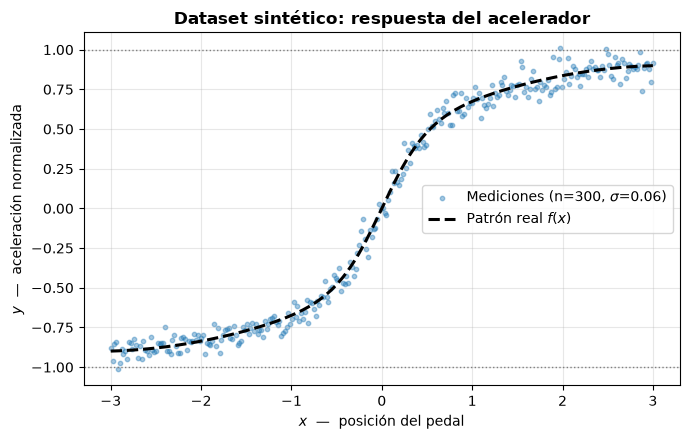

In [119]:
import time
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# DATASET SINTÉTICO
# ----------------------------------------------------------------------
N     = 300    # cantidad de muestras
SIGMA = 0.06   # desvío del ruido de medición

# Barrido del pedal: 300 posiciones equiespaciadas, de freno a fondo a acelerador a fondo
x = np.linspace(-3, 3, N)

def patron_no_lineal(x):
    """Curva 'real' del auto: techo de aceleración (tanh) + compresión suave (sin)."""
    return 0.5 * np.tanh(2 * x) + 0.4 * np.sin(0.5 * x)

# Generador propio para el ruido, con semilla fija -> el dataset es siempre el mismo.
# Se usa un generador separado del de la inicialización de parámetros para que ambas
# cosas sean reproducibles de forma independiente.
rng_datos = np.random.default_rng(42)
y = patron_no_lineal(x) + rng_datos.normal(0, SIGMA, N)

print(f"x : {N} puntos en [{x.min():.1f}, {x.max():.1f}]")
print(f"y : senal limpia en [{patron_no_lineal(x).min():.3f}, {patron_no_lineal(x).max():.3f}], con ruido [{y.min():.3f}, {y.max():.3f}]")
print(f"Piso de error por ruido: sigma^2 nominal = {SIGMA**2:.5f}, realizado = {np.mean((y-patron_no_lineal(x))**2):.5f}")

# La curva elegida es estrictamente creciente en todo el rango
derivada = (1 - np.tanh(2*x)**2) + 0.2*np.cos(0.5*x)
print(f"f'(x) minimo en el rango = {derivada.min():.4f}  -> monotona creciente: {derivada.min() > 0}")

plt.figure(figsize=(7, 4.5))
plt.scatter(x, y, s=10, alpha=0.4, label=f"Mediciones (n={N}, $\\sigma$={SIGMA})")
plt.plot(x, patron_no_lineal(x), "k--", lw=2.2, label="Patrón real $f(x)$")
plt.axhline( 1, color="gray", ls=":", lw=1)
plt.axhline(-1, color="gray", ls=":", lw=1)
plt.xlabel("$x$  —  posición del pedal")
plt.ylabel("$y$  —  aceleración normalizada")
plt.title("Dataset sintético: respuesta del acelerador", fontweight="bold")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Derivación del gradiente

La cadena completa es:

$$J \;\longleftarrow\; \hat y \;\longleftarrow\; z \;\longleftarrow\; (w,\,b)$$

Derivando eslabón por eslabón:

$$\frac{\partial J}{\partial \hat y_i} = \frac{2}{m}\left(\hat y_i - y_i\right)
\qquad
\underbrace{\frac{\partial \hat y_i}{\partial z_i} = 1 - \tanh^2(z_i) = 1 - \hat y_i^{\,2}}_{\text{eslabón nuevo}}
\qquad
\frac{\partial z_i}{\partial w} = x_i
\qquad
\frac{\partial z_i}{\partial b} = 1$$

Multiplicando la cadena y sumando sobre las $m$ muestras:

$$\boxed{\;\frac{\partial J}{\partial w} = \frac{2}{m}\sum_{i=1}^{m}\left(\hat y_i - y_i\right)\left(1 - \hat y_i^{\,2}\right)x_i
\qquad
\frac{\partial J}{\partial b} = \frac{2}{m}\sum_{i=1}^{m}\left(\hat y_i - y_i\right)\left(1 - \hat y_i^{\,2}\right)\;}$$

Si el modelo no tuviera la `tanh` y fuera simplemente $\hat y = wx+b$, el gradiente sería este mismo pero sin el factor $\left(1 - \hat y_i^{\,2}\right)$. O sea que toda la diferencia está ahí, y ese factor funciona como una válvula sobre la señal de error:

- Cuando $\hat y_i \approx 0$ el factor vale $\approx 1$, multiplica por uno y no atenúa nada: a $w$ y $b$ les llega la señal de error completa.
- Cuando $\hat y_i \to \pm 1$ el factor vale $\approx 0$ y divide la señal por un número grande. La neurona está saturada y la corrección se apaga sin importar cuán grande sea el error.

A lo segundo se le llama *vanishing gradient*: el gradiente se vuelve tan chico que los parámetros dejan de moverse, y no porque el algoritmo haya llegado al mínimo sino porque la señal que le indica hacia dónde ir se atenuó en el camino. Son dos situaciones opuestas que desde afuera se ven iguales.

En el punto donde arranca este experimento las 300 predicciones caen entre $0.960$ y $0.985$, todas pegadas al techo, y el factor promedia $0.0506$. El gradiente termina valiendo $0.206$ cuando sin la saturación valdría $3.095$: una atenuación de 15 veces (no exactamente las 20 que daría el promedio del factor, porque el factor no vale lo mismo para todas las muestras). El error es enorme y la señal cruda también, pero casi nada de eso llega a los parámetros.

Acá el efecto aparece con una sola capa y un único factor. El nombre viene de las redes profundas, donde estos factores se multiplican capa por capa: $0.05$ elevado a diez capas da $10^{-13}$ y el gradiente desaparece del todo.

La saturación es también la responsable del rasgo más incómodo de esta superficie para entrenar: zonas donde el costo es altísimo y el gradiente está casi apagado. Conviene aclarar que la no convexidad de $J$ en sí no la trae la saturación, sino componer el error cuadrático, que sí es convexo, con una `tanh` que no es lineal; hay curvatura negativa incluso donde nada está saturado. La saturación es el síntoma más visible, no la causa. En la interpretación del auto: si el modelo cree que el auto satura con cualquier toque del pedal, predice "a fondo" para las 300 mediciones, y cambiar un poco $w$ no modifica ninguna predicción. Las mediciones dejan de informar en qué dirección corregirse.

Nota de implementación: como $\hat y = \tanh(z)$, el factor $1-\hat y^2$ se calcula reutilizando el resultado del forward pass, sin recomputar nada. (_backpropagation: guardar las activaciones de la ida para usarlas en la vuelta_)

In [120]:
# ----------------------------------------------------------------------
# FUNCIÓN DE COSTO Y GRADIENTE
# ----------------------------------------------------------------------

def costo(w, b):
    """J(w,b) = (1/m) * sum( (y_hat - y)^2 )   con y_hat = tanh(w*x + b)"""
    y_hat = np.tanh(w * x + b)
    return np.mean((y_hat - y) ** 2)


def gradiente(w, b):
    """Versión vectorizada. Traduce literalmente las fórmulas derivadas arriba."""
    m = x.size                                     # se toma del array, no de la constante N
    y_hat = np.tanh(w * x + b)                     # forward pass
    delta = (2 / m) * (y_hat - y) * (1 - y_hat**2) # (2/m)·(y_hat - y)·(1 - y_hat²)
    dJ_dw = np.sum(delta * x)                      #   ... · x_i
    dJ_db = np.sum(delta)                          #   ... · 1
    return dJ_dw, dJ_db


def gradiente_con_for(w, b):
    """Misma fórmula, sumando muestra por muestra. Solo para verificar la vectorizada."""
    m = x.size
    dJ_dw = 0.0
    dJ_db = 0.0
    for i in range(m):
        y_hat_i = np.tanh(w * x[i] + b)
        delta_i = (2 / m) * (y_hat_i - y[i]) * (1 - y_hat_i**2)
        dJ_dw += delta_i * x[i]
        dJ_db += delta_i
    return dJ_dw, dJ_db


# --- Verificación: ambas implementaciones deben coincidir ---
w_test, b_test = 0.5, -0.3
g_vec = gradiente(w_test, b_test)
g_for = gradiente_con_for(w_test, b_test)

assert np.allclose(g_vec, g_for), "Las dos implementaciones del gradiente no coinciden"

print(f"Gradiente en (w={w_test}, b={b_test}):")
print(f"  con bucle explícito : dJ/dw = {g_for[0]:+.10f}   dJ/db = {g_for[1]:+.10f}")
print(f"  vectorizado         : dJ/dw = {g_vec[0]:+.10f}   dJ/db = {g_vec[1]:+.10f}")
print("  assert OK -> mismo resultado\n")

# --- Por qué se usa la vectorizada de acá en adelante ---
t0 = time.perf_counter(); [gradiente(w_test, b_test)         for _ in range(200)]; t_vec = time.perf_counter() - t0
t0 = time.perf_counter(); [gradiente_con_for(w_test, b_test) for _ in range(200)]; t_for = time.perf_counter() - t0
print(f"200 evaluaciones: vectorizado {t_vec*1e3:6.1f} ms | con bucle {t_for*1e3:6.1f} ms  ->  {t_for/t_vec:.0f}x más rápido")

Gradiente en (w=0.5, b=-0.3):
  con bucle explícito : dJ/dw = -0.2654244554   dJ/db = -0.2945783155
  vectorizado         : dJ/dw = -0.2654244554   dJ/db = -0.2945783155
  assert OK -> mismo resultado

200 evaluaciones: vectorizado    1.5 ms | con bucle   28.5 ms  ->  19x más rápido


#### Full-batch y la inicialización

Un *batch* es el conjunto de muestras con el que se calcula una actualización de los parámetros. Acá el gradiente se calcula siempre con las 300 muestras del dataset, que es lo que se llama *full-batch*: cada época produce exactamente una actualización, así que 100 épocas son 100 actualizaciones. La ventaja es que ese gradiente es el gradiente exacto de $J$, sin aproximación, y la trayectoria sale suave y determinista. La desventaja es la cantidad de actualizaciones: hay que recorrer las 300 muestras enteras para corregirse una sola vez.

Sobre la inicialización, $w$ y $b$ se generan con `np.random.randn()` una sola vez, con semilla fija, y quedan guardados en `W0` y `B0` para que los tres learning rates arranquen exactamente del mismo punto. Si cada corrida empezara en otro lado las curvas no serían comparables y el experimento no mediría el efecto del learning rate.

Vale aclarar qué hace la semilla, porque no quita que los valores sean aleatorios. `np.random.randn()` es un generador pseudoaleatorio: produce números a partir de un estado interno siguiendo un algoritmo determinista. `np.random.seed(18)` fija ese estado, de modo que la secuencia que sale es siempre la misma en cualquier máquina. Los valores siguen siendo una muestra legítima de una $\mathcal{N}(0,1)$, no están escritos a mano; lo único que queda fijado es cuál de todas las secuencias posibles toca. Sin semilla, cada ejecución del notebook daría parámetros iniciales distintos y el análisis escrito más abajo no coincidiría con los números que se obtienen al correrlo.

Elegir qué semilla usar sí es una decisión mía y prefiero dejarla a la vista. La celda siguiente imprime el punto de arranque de cuatro semillas. Con las semillas 0, 7 y 42 el costo inicial ya está entre 0.03 y 0.06, o sea que el modelo arranca prácticamente resuelto y los tres learning rates terminan dando curvas parecidas entre sí. La semilla 18 arranca con costo 1.47 y la neurona saturada, con el gradiente atenuado 15 veces por ese motivo. Es un punto de partida poco frecuente pero perfectamente alcanzable por `randn()`, y el único de los cuatro donde el learning rate cambia el resultado de manera visible.

In [121]:
# ----------------------------------------------------------------------
# ALGORITMO DEL GRADIENTE DESCENDENTE (GD)
# ----------------------------------------------------------------------
EPOCAS = 100
LRS    = [0.1, 0.01, 0.001]

def entrenar_gd(w0, b0, lr, epocas=EPOCAS):
    """
    GD full-batch. Devuelve el historial completo de (w, b, J).

    Se guardan también w y b, no solo el costo, para poder reconstruir después
    la trayectoria que recorre el algoritmo en el espacio de parámetros.

    Convención: el historial arranca con el punto inicial (época 0) y agrega
    un valor por cada actualización, de modo que len(historial) = epocas + 1.
    """
    w, b = w0, b0
    hist_w, hist_b, hist_J = [w], [b], [costo(w, b)]

    for _ in range(epocas):                 # <-- el bucle de épocas: el proceso iterativo
        dJ_dw, dJ_db = gradiente(w, b)      # 1. gradiente con TODO el dataset (full-batch)
        w = w - lr * dJ_dw                  # 2. actualización del peso
        b = b - lr * dJ_db                  # 3. actualización del bias
        hist_w.append(w); hist_b.append(b); hist_J.append(costo(w, b))

    return np.array(hist_w), np.array(hist_b), np.array(hist_J)


# --- Por qué esta semilla: punto de arranque de varias semillas ---
print("Punto de arranque según la semilla:")
for s in (0, 7, 18, 42):
    np.random.seed(s)
    w_s, b_s = np.random.randn(), np.random.randn()
    print(f"  seed={s:>3}:  w0={w_s:+.4f}  b0={b_s:+.4f}   J={costo(w_s, b_s):.4f}   ||grad||={np.hypot(*gradiente(w_s, b_s)):.4f}")
print()

# --- Inicialización: una sola vez, la misma para los tres learning rates ---
np.random.seed(18)
W0 = np.random.randn()
B0 = np.random.randn()

norma_grad_inicial = np.hypot(*gradiente(W0, B0))
print(f"Inicialización:  w0 = {W0:.4f}   b0 = {B0:.4f}")
print(f"  J(w0, b0)      = {costo(W0, B0):.4f}   <- costo alto")
# El gradiente no es chico en términos absolutos: es chico COMPARADO con el error.
# Sin el factor de saturación (1 - y_hat²) valdría mucho más.
y_hat_0   = np.tanh(W0 * x + B0)
factor_0  = 1 - y_hat_0**2
error_0   = (2 / x.size) * (y_hat_0 - y)
grad_sin_saturacion = np.hypot(np.sum(error_0 * x), np.sum(error_0))

print(f"  ||grad(w0,b0)||= {norma_grad_inicial:.4f}")
print(f"    y_hat inicial va de {y_hat_0.min():.4f} a {y_hat_0.max():.4f}  -> las 300 predicciones pegadas al techo")
print(f"    factor (1 - y_hat^2) promedio = {factor_0.mean():.4f}")
print(f"    sin ese factor el gradiente valdría {grad_sin_saturacion:.4f}  -> la saturación lo atenúa {grad_sin_saturacion/norma_grad_inicial:.1f} veces\n")

# --- Entrenamiento con los 3 learning rates, desde el MISMO punto inicial ---
hist_gd = {lr: entrenar_gd(W0, B0, lr) for lr in LRS}

print(f"{'lr':>7} | {'J inicial':>10} | {'J final':>10} | {'reducción':>10} | {'w final':>8} | {'b final':>8}")
print("-" * 70)
for lr in LRS:
    h_w, h_b, h_J = hist_gd[lr]
    print(f"{lr:>7} | {h_J[0]:>10.5f} | {h_J[-1]:>10.5f} | {100*(1-h_J[-1]/h_J[0]):>9.1f}% | {h_w[-1]:>8.4f} | {h_b[-1]:>8.4f}")

# Cómo evoluciona el gradiente a lo largo de la corrida de lr=0.1, y qué modelo queda con lr=0.001
h_w, h_b, _ = hist_gd[0.1]
normas = np.array([np.hypot(*gradiente(w, b)) for w, b in zip(h_w, h_b)])
print(f"\nlr=0.1  : ||grad|| arranca en {normas[0]:.4f} y llega a {normas.max():.4f} en la época {normas.argmax()} "
      f"({normas.max()/normas[0]:.1f} veces más grande)")
h_w, h_b, _ = hist_gd[0.001]
pred = np.tanh(h_w[-1] * x + h_b[-1])
print(f"lr=0.001: el modelo final predice entre {pred.min():.4f} y {pred.max():.4f} para todo x -> casi una constante")

Punto de arranque según la semilla:
  seed=  0:  w0=+1.7641  b0=+0.4002   J=0.0530   ||grad||=0.0725
  seed=  7:  w0=+1.6905  b0=-0.4659   J=0.0560   ||grad||=0.0855
  seed= 18:  w0=+0.0794  b0=+2.1902   J=1.4750   ||grad||=0.2061
  seed= 42:  w0=+0.4967  b0=-0.1383   J=0.0346   ||grad||=0.2330

Inicialización:  w0 = 0.0794   b0 = 2.1902
  J(w0, b0)      = 1.4750   <- costo alto
  ||grad(w0,b0)||= 0.2061
    y_hat inicial va de 0.9605 a 0.9846  -> las 300 predicciones pegadas al techo
    factor (1 - y_hat^2) promedio = 0.0506
    sin ese factor el gradiente valdría 3.0953  -> la saturación lo atenúa 15.0 veces

     lr |  J inicial |    J final |  reducción |  w final |  b final
----------------------------------------------------------------------
    0.1 |    1.47500 |    0.03899 |      97.4% |   1.5156 |   0.2707
   0.01 |    1.47500 |    1.21768 |      17.4% |   0.4679 |   1.9693
  0.001 |    1.47500 |    1.47035 |       0.3% |   0.0972 |   2.1780

lr=0.1  : ||grad|| arranca en 0.

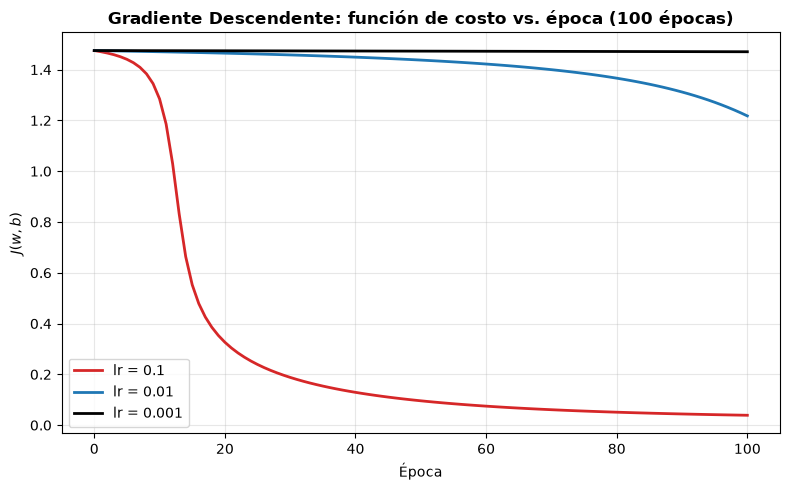

In [122]:
# ----------------------------------------------------------------------
# GRÁFICA: J(w,b) vs ÉPOCA, los 3 learning rates superpuestos
# ----------------------------------------------------------------------
# Rojo/azul/negro en vez de rojo/azul/verde: el par rojo-verde es indistinguible
# para el tipo de daltonismo más común.
COLORES = {0.1: "#d62728", 0.01: "#1f77b4", 0.001: "#000000"}

plt.figure(figsize=(8, 5))
for lr in LRS:
    plt.plot(hist_gd[lr][2], color=COLORES[lr], lw=2, label=f"lr = {lr}")

plt.xlabel("Época")
plt.ylabel("$J(w,b)$")
plt.title("Gradiente Descendente: función de costo vs. época (100 épocas)", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Análisis de los resultados

| lr | J inicial | J final | Reducción | w final | b final |
|---|---|---|---|---|---|
| 0.1 | 1.4750 | 0.0390 | 97.4 % | 1.5156 | 0.2707 |
| 0.01 | 1.4750 | 1.2177 | 17.4 % | 0.4679 | 1.9693 |
| 0.001 | 1.4750 | 1.4704 | 0.3 % | 0.0972 | 2.1780 |

De los tres learning rates, 0.1 es el único con el que el modelo aprende algo en 100 épocas. Con 0.01 queda a mitad de camino y con 0.001 no arranca.

La curva de $lr=0.1$ no baja parejo como esperaba, sino en tres tramos: las primeras 8 épocas casi no se mueve, entre la 10 y la 20 se desploma, y después baja cada vez más lento.

El arranque lento es la saturación. El gradiente ahí vale 0.206, que en términos absolutos no es chico (la semilla 42 arranca con 0.233 estando casi resuelta), pero sí es chico para el error que hay: sin la saturación valdría 3.095, quince veces más. Como GD avanza el learning rate por el gradiente, eso da 0.02 por época incluso con el learning rate más grande de los tres.

Tampoco es una meseta plana, es el borde de una caída. El gradiente pasa de 0.206 a 1.404 en la época 12, cuando $b$ bajó lo suficiente para sacar a la neurona de la saturación: ahí el factor $(1-\hat y^2)$ se despierta y la bajada se acelera sola. El tercer tramo es el gradiente achicándose otra vez, ahora por estar cerca del mínimo. En la época 100 la curva todavía baja, así que ni el mejor de los tres terminó.

A $lr=0.001$ conviene mirar los parámetros y no el costo. Terminó en $w=0.097$ y $b=2.178$, un modelo que predice entre 0.955 y 0.986 para todo $x$: una línea horizontal pegada al techo. En la historia del auto, dice que el vehículo acelera a fondo siempre, se pise el freno o el acelerador.

Uno esperaría que bajar el learning rate de 0.1 a 0.001 hiciera el entrenamiento 100 veces más lento, pero el efecto se multiplica con la saturación: el avance es el learning rate por el gradiente, y los dos factores son chicos a la vez. Con $lr=0.001$ el modelo se mueve 0.0002 por época y en 100 épocas recorre 0.02. No va lento, está frenado.

Y GD no tiene cómo distinguir un gradiente chico por saturación de uno chico por estar cerca del mínimo. En los dos casos avanza poco, y son situaciones opuestas.

### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno full-batch y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

#### Respuesta 1.b

Adam guarda dos promedios móviles de lo que viene pasando con el gradiente. En cada actualización $t$, siendo $g_t$ el gradiente actual:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\,g_t \qquad\qquad v_t = \beta_2 v_{t-1} + (1-\beta_2)\,g_t^{2}$$

$m_t$ es el promedio del gradiente reciente, o sea hacia dónde viene apuntando de forma consistente. $v_t$ es el promedio del cuadrado, o sea qué tan grande viene siendo, sin importar el signo. Los dos arrancan en cero, lo que los sesga hacia abajo en las primeras iteraciones, y por eso se corrigen:

$$\hat m_t = \frac{m_t}{1-\beta_1^{\,t}} \qquad\qquad \hat v_t = \frac{v_t}{1-\beta_2^{\,t}}$$

Y la actualización queda:

$$w_t = w_{t-1} - \eta\,\frac{\hat m^{(w)}_t}{\sqrt{\hat v^{(w)}_t}+\epsilon} \qquad\qquad b_t = b_{t-1} - \eta\,\frac{\hat m^{(b)}_t}{\sqrt{\hat v^{(b)}_t}+\epsilon}$$

Cada parámetro lleva sus propios $m$ y $v$, calculados con su propio gradiente. Si compartieran los momentos, $w$ y $b$ recibirían siempre la misma corrección.

La clave está en el cociente $\hat m_t / \sqrt{\hat v_t}$. Si el gradiente viene siendo más o menos constante e igual a $g$, entonces $\hat m_t \approx g$ y $\sqrt{\hat v_t} \approx |g|$, así que el cociente da $\pm 1$ y lo que se mueve termina siendo $\eta$. El gradiente se cancela contra sí mismo: Adam lo usa para decidir hacia dónde ir, no cuánto avanzar.

Eso es justo lo que le faltaba al GD en la meseta. GD se mueve el learning rate multiplicado por el gradiente, y con el gradiente valiendo 0.206 el avance se le achicaba solo. Adam avanza el learning rate aunque el gradiente esté casi apagado.

Uso los valores por defecto del paper original, $\beta_1 = 0.9$, $\beta_2 = 0.999$ y $\epsilon = 10^{-8}$.

##### Full-batch y mini-batch

La diferencia entre las dos versiones no está en Adam, sino en con cuántas muestras se calcula cada gradiente:

| | Muestras por gradiente | Lotes por época | Actualizaciones en 100 épocas |
|---|---|---|---|
| Full-batch | 300 | 1 | 100 |
| Mini-batch (32) | 32 | 10 | 1000 |

Elegí un batch size de 32. Con 300 muestras quedan 10 lotes por época, nueve de 32 y uno de 12. La actualización de $w$ y $b$ se hace después de cada lote, no al final de la época, así que hay 10 actualizaciones por época en lugar de una. El mini-batch no espera a ver las 300 muestras para corregirse: mira 32, corrige, mira otras 32, corrige, y así diez veces.

Hay algo que no es evidente y conviene dejar anotado: las dos versiones hacen la misma cantidad de cuentas por época. Las dos miran las 300 muestras. El full-batch gasta todas esas cuentas en calcular una dirección exacta y corregirse una vez; el mini-batch las gasta en corregirse diez veces, cada una apuntada con la información de solo 32 muestras. No trabaja más: convierte el mismo trabajo en más correcciones, a cambio de que cada dirección sea aproximada.

Las muestras se barajan al principio de cada época, y acá eso no es un detalle: `x` está ordenado de menor a mayor, así que sin barajar cada lote cubriría siempre el mismo tramo del pedal. El primer lote tendría solo frenadas y el último solo aceleraciones, y los gradientes saldrían sistemáticamente sesgados en lugar de ruidosos.

In [123]:
# ----------------------------------------------------------------------
# ADAM (full-batch y mini-batch)
# ----------------------------------------------------------------------
BATCH = 32

def gradiente_lote(w, b, x_lote, y_lote):
    """Mismo gradiente que en 1a, pero sobre un subconjunto de muestras."""
    m = len(x_lote)
    y_hat = np.tanh(w * x_lote + b)
    delta = (2 / m) * (y_hat - y_lote) * (1 - y_hat**2)
    return np.sum(delta * x_lote), np.sum(delta)

# El gradiente full-batch es el caso particular en que el lote es el dataset entero
assert np.allclose(gradiente(0.5, -0.3), gradiente_lote(0.5, -0.3, x, y))


def entrenar_adam(w0, b0, lr, epocas=EPOCAS, batch_size=None,
                  beta1=0.9, beta2=0.999, eps=1e-8, semilla_lotes=0):
    """
    Adam. Con batch_size=None entrena full-batch (una actualización por época);
    con un batch_size entero entrena mini-batch (una actualización por lote).

    El costo que se guarda en el historial es siempre el del dataset completo,
    para que las curvas de ambas versiones sean comparables entre sí.
    """
    w, b = w0, b0
    m_w = m_b = 0.0          # primer momento: promedio del gradiente
    v_w = v_b = 0.0          # segundo momento: promedio del gradiente al cuadrado
    t = 0                    # contador de actualizaciones (para la corrección de sesgo)

    rng_lotes = np.random.default_rng(semilla_lotes)
    hist_w, hist_b, hist_J = [w], [b], [costo(w, b)]

    for _ in range(epocas):
        if batch_size is None:
            lotes = [np.arange(N)]                                    # un lote: todo el dataset
        else:
            orden = rng_lotes.permutation(N)                          # se baraja en cada época
            lotes = [orden[i:i + batch_size] for i in range(0, N, batch_size)]

        for idx in lotes:
            t += 1
            dJ_dw, dJ_db = gradiente_lote(w, b, x[idx], y[idx])

            m_w = beta1 * m_w + (1 - beta1) * dJ_dw                   # momentos
            m_b = beta1 * m_b + (1 - beta1) * dJ_db
            v_w = beta2 * v_w + (1 - beta2) * dJ_dw**2
            v_b = beta2 * v_b + (1 - beta2) * dJ_db**2

            m_w_hat = m_w / (1 - beta1**t)                            # corrección de sesgo
            m_b_hat = m_b / (1 - beta1**t)
            v_w_hat = v_w / (1 - beta2**t)
            v_b_hat = v_b / (1 - beta2**t)

            w = w - lr * m_w_hat / (np.sqrt(v_w_hat) + eps)           # actualización
            b = b - lr * m_b_hat / (np.sqrt(v_b_hat) + eps)

        hist_w.append(w); hist_b.append(b); hist_J.append(costo(w, b))

    return np.array(hist_w), np.array(hist_b), np.array(hist_J)


# --- Entrenamiento desde los MISMOS W0 y B0 que usó GD en 1a ---
hist_adam_fb = {lr: entrenar_adam(W0, B0, lr)                     for lr in LRS}
hist_adam_mb = {lr: entrenar_adam(W0, B0, lr, batch_size=BATCH)   for lr in LRS}

print(f"Punto de partida: w0 = {W0:.4f}, b0 = {B0:.4f}, J = {costo(W0, B0):.4f}   (el mismo que en 1a)\n")
print(f"{'lr':>7} | {'Adam full-batch':>16} | {'Adam mini-batch':>16}")
print("-" * 46)
for lr in LRS:
    print(f"{lr:>7} | {hist_adam_fb[lr][2][-1]:>16.5f} | {hist_adam_mb[lr][2][-1]:>16.5f}")

# --- ¿El paso de Adam vale el learning rate? ---
print(f"\nCambio promedio de w en cada actualización (primeras 10 épocas):")
print(f"{'lr':>7} | {'Adam':>8} | {'GD':>8}")
print("-" * 29)
for lr in LRS:
    paso_adam = np.abs(np.diff(hist_adam_fb[lr][0]))[:10].mean()
    paso_gd   = np.abs(np.diff(hist_gd[lr][0]))[:10].mean()
    print(f"{lr:>7} | {paso_adam:>8.4f} | {paso_gd:>8.4f}")

# --- ¿Se queda quieto al llegar al mínimo? ---
print(f"\nÚltimas 30 épocas del mini-batch:")
print(f"{'lr':>7} | {'J mínimo':>9} | {'J máximo':>9} | {'J final':>9} | {'cambio de w por época':>22}")
print("-" * 70)
for lr in LRS:
    h_w, _, h_J = hist_adam_mb[lr]
    vaiven = np.abs(np.diff(h_w[-30:])).mean()
    print(f"{lr:>7} | {h_J[-30:].min():>9.5f} | {h_J[-30:].max():>9.5f} | {h_J[-1]:>9.5f} | {vaiven:>22.4f}")

# --- Control: ¿el sobrepaso de Adam es el precio de su velocidad? ---
# beta1=0 desactiva el momento y deja solo la normalización por sqrt(v).
print(f"\nAdam full-batch con y sin momento:")
print(f"{'lr':>7} | {'beta1':>6} | {'época a J<0.05':>15} | {'J final':>9}")
print("-" * 46)
for lr in (0.1, 0.01):
    for b1 in (0.9, 0.0):
        _, _, h_J = entrenar_adam(W0, B0, lr, beta1=b1)
        i = int(np.argmax(h_J < 0.05))
        cruce = str(i) if h_J[i] < 0.05 else "no llega"
        print(f"{lr:>7} | {b1:>6} | {cruce:>15} | {h_J[-1]:>9.5f}")

print(f"\nParámetros finales:")
print(f"{'lr':>7} | {'Adam FB (w, b)':>22} | {'Adam MB (w, b)':>22}")
print("-" * 58)
for lr in LRS:
    fb, mb = hist_adam_fb[lr], hist_adam_mb[lr]
    print(f"{lr:>7} | {fb[0][-1]:>10.4f}, {fb[1][-1]:>9.4f} | {mb[0][-1]:>10.4f}, {mb[1][-1]:>9.4f}")

Punto de partida: w0 = 0.0794, b0 = 2.1902, J = 1.4750   (el mismo que en 1a)

     lr |  Adam full-batch |  Adam mini-batch
----------------------------------------------
    0.1 |          0.02929 |          0.00910
   0.01 |          0.20929 |          0.00874
  0.001 |          1.43143 |          0.21706

Cambio promedio de w en cada actualización (primeras 10 épocas):
     lr |     Adam |       GD
-----------------------------
    0.1 |   0.0959 |   0.0329
   0.01 |   0.0101 |   0.0018
  0.001 |   0.0010 |   0.0002

Últimas 30 épocas del mini-batch:
     lr |  J mínimo |  J máximo |   J final |  cambio de w por época
----------------------------------------------------------------------
    0.1 |   0.00874 |   0.00910 |   0.00910 |                 0.0126
   0.01 |   0.00874 |   0.00934 |   0.00874 |                 0.0025
  0.001 |   0.21706 |   0.35316 |   0.21706 |                 0.0044

Adam full-batch con y sin momento:
     lr |  beta1 |  época a J<0.05 |   J final
---------

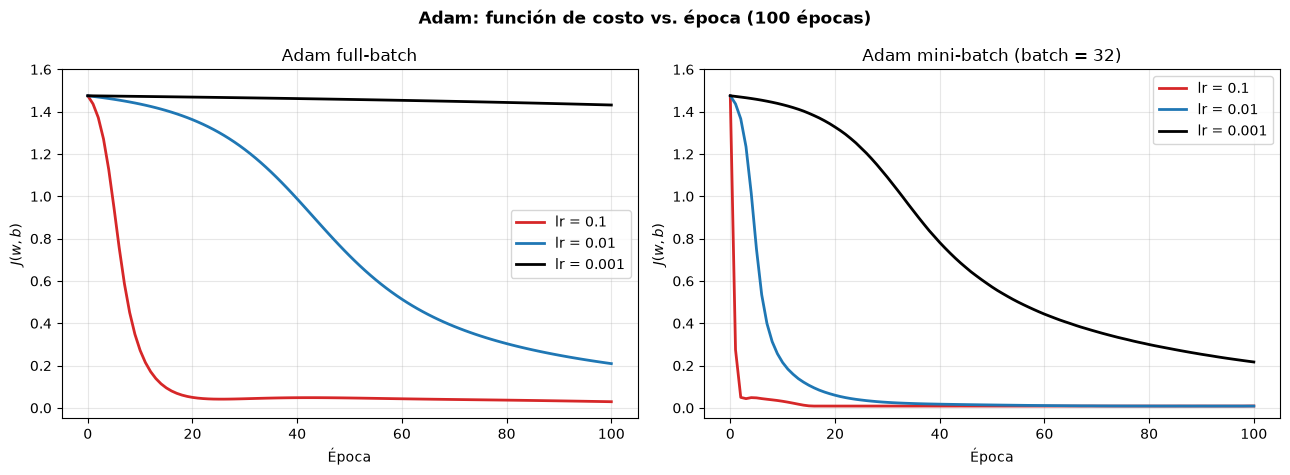

In [124]:
# ----------------------------------------------------------------------
# GRÁFICA: Adam full-batch y Adam mini-batch, los 3 learning rates
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for ax, hist, titulo in zip(axes,
                            [hist_adam_fb, hist_adam_mb],
                            ["Adam full-batch", f"Adam mini-batch (batch = {BATCH})"]):
    for lr in LRS:
        ax.plot(hist[lr][2], color=COLORES[lr], lw=2, label=f"lr = {lr}")
    ax.set_xlabel("Época")
    ax.set_ylabel("$J(w,b)$")
    ax.set_title(titulo)
    ax.set_ylim(-0.05, 1.6)
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("Adam: función de costo vs. época (100 épocas)", fontweight="bold")
fig.tight_layout()
plt.show()

#### Análisis de los resultados

| lr | Adam full-batch | Adam mini-batch |
|---|---|---|
| 0.1 | 0.02929 | 0.00910 |
| 0.01 | 0.20929 | 0.00874 |
| 0.001 | 1.43143 | 0.21706 |

Adam le gana a GD en los tres learning rates, y la razón es cuánto avanza cada uno en cada corrección. GD multiplica el learning rate por el gradiente, así que donde el gradiente es chico avanza poco. Adam divide el gradiente por su propia magnitud, así que avanza siempre lo mismo. Midiendo cuánto cambia $w$ en cada actualización durante las primeras 10 épocas:

| lr | Adam | GD |
|---|---|---|
| 0.1 | 0.0959 | 0.0329 |
| 0.01 | 0.0101 | 0.0018 |
| 0.001 | 0.0010 | 0.0002 |

El avance de Adam es el learning rate y nada más: 0.0101 con $lr=0.01$, 0.0010 con $lr=0.001$. GD avanza según dónde esté parado, y con la neurona saturada le queda entre 3 y 6 veces menos.

Eso le alcanza al full-batch para mejorar bastante con $lr=0.01$, de 1.218 a 0.209, pero no para converger. Con 100 correcciones de 0.01 recorre alrededor de una unidad por eje, y desde $b_0=2.19$ hasta el mínimo hay más de dos. El problema ya no es cuánto avanza, es que se corrige pocas veces.

El mini-batch arregla eso corrigiéndose 10 veces por época. Con $lr=0.01$ le sobra distancia y termina en 0.00874, el mínimo de la superficie. Con $lr=0.001$ llega a 0.217, que casi iguala al full-batch con un learning rate diez veces más grande.

El mini-batch con $lr=0.1$ cruza 0.05 en 2 épocas contra 22 con $lr=0.01$, y termina en 0.00910 contra 0.00874. Leí esa diferencia como que $lr=0.1$ convergía peor, pero mirando las últimas 30 épocas no es eso: ninguno de los dos se queda quieto, los dos oscilan en una banda de 0.0087 a 0.0093, y el número final es dónde estaba cada uno en la época 100. Oscilan porque cada corrección usa un gradiente de 32 muestras, y cerca del mínimo ese ruido es lo único que queda. El tamaño del vaivén sí depende del learning rate: $w$ se mueve 0.0126 por época con $lr=0.1$ y 0.0025 con $lr=0.01$.

La curva del full-batch con $lr=0.1$ tampoco baja pareja: toca 0.0422 en la época 28, sube a 0.0485 en la 43 y después sigue. La causa es el momento, que arrastra los gradientes anteriores y lo hace pasarse de largo al llegar al valle. Pensé que era el precio de la velocidad, así que lo probé con $\beta_1 = 0$: sin momento cruza 0.05 en la época 21 en vez de la 20, y termina en 0.00874 en vez de 0.02929. Cuesta una época y mejora el resultado 3.4 veces. Acá el momento no aporta velocidad, solo sobrepaso; la velocidad viene de dividir por $\sqrt{\hat v_t}$.

### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate. Y las leyendas deben diferenciar al optimizador por color.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes. Le voy a tomar mucha importancia a este último punto, así que su análisis debe ser claro, detallado y con criterio acorde a los resultados obtenidos.

#### Respuesta 1.c

Para esta comparación cambio el criterio de color: en 1a y 1b cada color era un learning rate, y de acá en adelante cada color es un optimizador (gris para GD, naranja para Adam full-batch, violeta para Adam mini-batch). Cada subplot es un learning rate.

Además del costo final agrego dos medidas de rendimiento. Una es cuántas épocas tarda cada uno en bajar de $J = 0.05$, que tomo como umbral de "el modelo ya aprendió el patrón" (el mínimo alcanzable es 0.0087, así que 0.05 está claramente del lado bueno). La otra es el tiempo de cómputo, para ver qué cuesta cada mejora.

In [125]:
# ----------------------------------------------------------------------
# TABLA COMPARATIVA: GD vs Adam full-batch vs Adam mini-batch
# ----------------------------------------------------------------------
import timeit

UMBRAL = 0.05

HISTORIALES_NOMBRES = ["GD", "Adam full-batch", "Adam mini-batch"]

OPTIMIZADORES = {
    "GD":             (lambda lr: entrenar_gd(W0, B0, lr),                    hist_gd,      1),
    "Adam full-batch":(lambda lr: entrenar_adam(W0, B0, lr),                  hist_adam_fb, 1),
    "Adam mini-batch":(lambda lr: entrenar_adam(W0, B0, lr, batch_size=BATCH), hist_adam_mb, int(np.ceil(N / BATCH))),
}

def epocas_hasta(hist_J, umbral):
    """Primera época en que el costo baja del umbral. None si nunca lo cruza."""
    i = int(np.argmax(hist_J < umbral))
    return i if hist_J[i] < umbral else None

print(f"{'lr':>7} | {'optimizador':<16} | {'J final':>9} | {'ep. a J<0.05':>12} | {'updates (100 ép.)':>18} | {'tiempo (ms)':>11}")
print("-" * 82)
for lr in LRS:
    for nombre, (entrenar, hist, ups_por_epoca) in OPTIMIZADORES.items():
        hist_J = hist[lr][2]
        # se cronometra con el mejor de 15 repeticiones: una sola medición varía demasiado
        # por carga de la máquina como para comparar nada
        tiempo = min(timeit.repeat(lambda: entrenar(lr), number=1, repeat=15)) * 1e3
        ep = epocas_hasta(hist_J, UMBRAL)
        print(f"{lr:>7} | {nombre:<16} | {hist_J[-1]:>9.5f} | {str(ep) if ep is not None else 'no llega':>12} | "
              f"{EPOCAS * ups_por_epoca:>18} | {tiempo:>11.1f}")
    print()

# --- De qué está hecho el mejor costo alcanzado ---
# J = mean((y_hat - f - ruido)^2) se abre en sesgo del modelo + ruido + término cruzado
nombre_mejor, lr_mejor = min(
    ((n, lr) for n in HISTORIALES_NOMBRES for lr in LRS),
    key=lambda k: OPTIMIZADORES[k[0]][1][k[1]][2][-1])
h_w, h_b, h_J = OPTIMIZADORES[nombre_mejor][1][lr_mejor]
y_hat = np.tanh(h_w[-1] * x + h_b[-1])
limpio = patron_no_lineal(x)
ruido  = y - limpio
sesgo    = np.mean((y_hat - limpio)**2)
ruido_t  = np.mean(ruido**2)
cruzado  = -2 * np.mean((y_hat - limpio) * ruido)

print(f"Mejor costo alcanzado: {h_J[-1]:.5f}  ({nombre_mejor}, lr={lr_mejor})")
print(f"  sesgo del modelo   = {sesgo:.5f}  ({100*sesgo/h_J[-1]:.0f}%)")
print(f"  ruido de los datos = {ruido_t:.5f}  ({100*ruido_t/h_J[-1]:.0f}%)")
print(f"  término cruzado    = {cruzado:+.5f}  ({100*cruzado/h_J[-1]:+.0f}%)")

# --- Control: ¿la ventaja del mini-batch es de Adam o de hacer más actualizaciones? ---
# Adam full-batch con 1000 épocas hace las mismas 1000 actualizaciones que el mini-batch.
print(f"\nIgualando actualizaciones (1000 en ambos):")
print(f"{'lr':>7} | {'Adam full-batch':>16} | {'Adam mini-batch':>16}")
print("-" * 46)
for lr in LRS:
    fb_1000 = entrenar_adam(W0, B0, lr, epocas=1000)[2][-1]
    print(f"{lr:>7} | {fb_1000:>16.5f} | {hist_adam_mb[lr][2][-1]:>16.5f}")

     lr | optimizador      |   J final | ep. a J<0.05 |  updates (100 ép.) | tiempo (ms)
----------------------------------------------------------------------------------
    0.1 | GD               |   0.03899 |           82 |                100 |         0.9
    0.1 | Adam full-batch  |   0.02929 |           20 |                100 |         1.5
    0.1 | Adam mini-batch  |   0.00910 |            2 |               1000 |         6.7

   0.01 | GD               |   1.21768 |     no llega |                100 |         1.0
   0.01 | Adam full-batch  |   0.20929 |     no llega |                100 |         1.2
   0.01 | Adam mini-batch  |   0.00874 |           22 |               1000 |         6.5

  0.001 | GD               |   1.47035 |     no llega |                100 |         0.9
  0.001 | Adam full-batch  |   1.43143 |     no llega |                100 |         1.2
  0.001 | Adam mini-batch  |   0.21706 |     no llega |               1000 |         7.1

Mejor costo alcanzado: 0

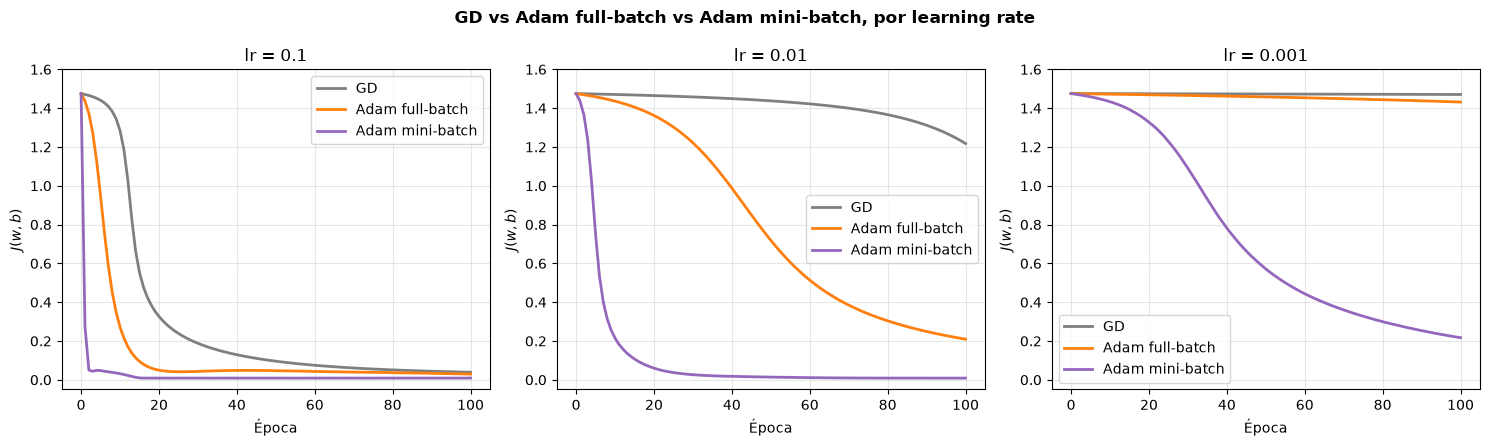

In [126]:
# ----------------------------------------------------------------------
# GRÁFICA: un subplot por learning rate, los 3 optimizadores superpuestos
# ----------------------------------------------------------------------
COL_OPT = {"GD": "tab:gray", "Adam full-batch": "tab:orange", "Adam mini-batch": "tab:purple"}
HISTORIALES = {"GD": hist_gd, "Adam full-batch": hist_adam_fb, "Adam mini-batch": hist_adam_mb}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, lr in zip(axes, LRS):
    for nombre, hist in HISTORIALES.items():
        ax.plot(hist[lr][2], color=COL_OPT[nombre], lw=2, label=nombre)
    ax.set_title(f"lr = {lr}")
    ax.set_xlabel("Época")
    ax.set_ylabel("$J(w,b)$")
    ax.set_ylim(-0.05, 1.6)
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("GD vs Adam full-batch vs Adam mini-batch, por learning rate", fontweight="bold")
fig.tight_layout()
plt.show()

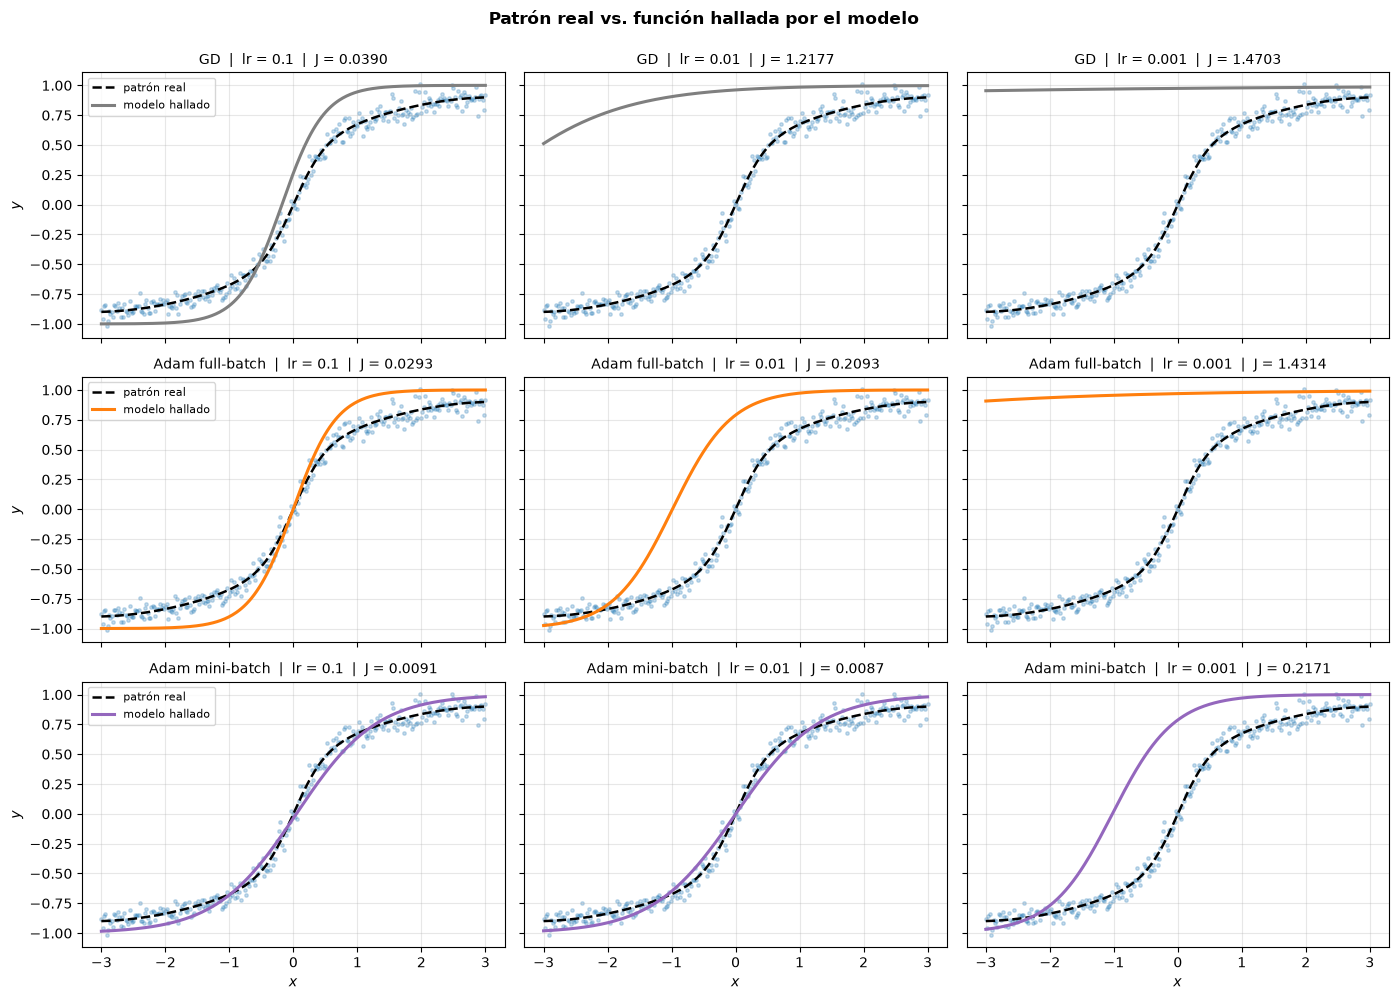

In [127]:
# ----------------------------------------------------------------------
# GRÁFICA: patrón real vs. función hallada, para cada optimizador y lr
# ----------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True)

for i, (nombre, hist) in enumerate(HISTORIALES.items()):
    for j, lr in enumerate(LRS):
        ax = axes[i, j]
        h_w, h_b, h_J = hist[lr]
        ax.scatter(x, y, s=6, alpha=0.25, color="tab:blue")
        ax.plot(x, patron_no_lineal(x), "k--", lw=1.8, label="patrón real")
        ax.plot(x, np.tanh(h_w[-1] * x + h_b[-1]), color=COL_OPT[nombre], lw=2.2, label="modelo hallado")
        ax.set_title(f"{nombre}  |  lr = {lr}  |  J = {h_J[-1]:.4f}", fontsize=10)
        ax.grid(alpha=0.3)
        if i == 2: ax.set_xlabel("$x$")
        if j == 0: ax.set_ylabel("$y$")
        if j == 0: ax.legend(fontsize=8, loc="upper left")

fig.suptitle("Patrón real vs. función hallada por el modelo", fontweight="bold", y=0.995)
fig.tight_layout()
plt.show()

#### Conclusiones

| lr | | J final | épocas a J<0.05 | actualizaciones en 100 épocas |
|---|---|---|---|---|
| 0.1 | GD | 0.03899 | 82 | 100 |
| | Adam full-batch | 0.02929 | 20 | 100 |
| | Adam mini-batch | 0.00910 | 2 | 1000 |
| 0.01 | GD | 1.21768 | no llega | 100 |
| | Adam full-batch | 0.20929 | no llega | 100 |
| | Adam mini-batch | 0.00874 | 22 | 1000 |
| 0.001 | GD | 1.47035 | no llega | 100 |
| | Adam full-batch | 1.43143 | no llega | 100 |
| | Adam mini-batch | 0.21706 | no llega | 1000 |

En los tres learning rates el orden es el mismo: primero Adam mini-batch, después full-batch y último GD. Los dos saltos tienen causas distintas.

De GD a Adam full-batch cambia cuánto avanzan. Los dos se corrigen 100 veces con el mismo gradiente exacto; la diferencia es que GD avanza poco cuando el gradiente es chico y Adam avanza siempre lo mismo. Con $lr=0.1$ terminan parecido, 0.039 y 0.029, pero Adam llega en 20 épocas y GD en 82. Con $lr=0.01$, donde el gradiente está atenuado toda la corrida, la diferencia salta a 1.218 contra 0.209.

De full-batch a mini-batch cambia cuántas veces se corrigen: 10 por época en vez de una. Por eso la ventaja aparece sobre todo con learning rates chicos, que es cuando falta distancia.

La velocidad medida en épocas favorece al mini-batch, porque cada época suya tiene 10 correcciones adentro. Contando correcciones, con $lr=0.1$ el mini-batch cruza el umbral en 20 y el full-batch también en 20: empatan. Para ver si aporta algo propio corrí Adam full-batch durante 1000 épocas, las mismas 1000 correcciones del mini-batch: da 0.00874, 0.00874 y 0.20985 contra 0.00910, 0.00874 y 0.21706. Son indistinguibles, y el full-batch queda apenas mejor en dos de los tres. Acá el mini-batch no aporta nada por sí mismo, toda su ventaja es meter más correcciones en el mismo presupuesto. Tiene sentido: con 300 muestras y dos parámetros, el gradiente de 32 ya es casi el exacto. En problemas grandes, donde recorrer todo el dataset es caro, ese mismo truco es lo que lo vuelve indispensable.

Con el learning rate pasa algo parecido. GD sirve con 1 de los 3, Adam full-batch también con 1, y el mini-batch con 2. Es tentador decir que Adam tolera un rango más ancho, pero la única comparación con presupuesto igualado, GD contra full-batch con 100 correcciones cada uno, da 1 de 3 contra 1 de 3. El margen lo da la cantidad de correcciones, no Adam.

El orden también depende de dónde se arranque. Probando GD contra Adam full-batch desde 200 semillas, GD gana por más de un 10% en 148 de las 600 combinaciones. Con la semilla 18 Adam gana en los tres learning rates, pero es porque arranca con la neurona saturada, que es justo el escenario donde su normalización rinde.

Los gráficos de ajuste agregan lo que la tabla no muestra. Con $lr=0.1$, GD y Adam full-batch dibujan una S demasiado empinada, $w=1.52$ y $w=1.48$ contra el 0.77 bueno: se estaban moviendo todavía cuando se acabaron las épocas. Con $lr=0.001$ los dos quedan en una línea horizontal arriba de todo, diciendo que el auto acelera a fondo sin importar el pedal.

Ni el mejor resultado, $J=0.00874$, copia el patrón exacto, y eso no es culpa del optimizador. Abriendo ese costo: 0.00524 es sesgo del modelo (60%), 0.00311 el ruido que le tocó a este dataset (36%) y 0.00039 un cruce entre los dos. La mayor parte de lo que queda es que una sola neurona con `tanh` no puede dibujar esa curva. Para bajar de ahí hay que cambiar el modelo, no el entrenamiento.

### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia. La comparación debe ser clara y detallada.

#### Respuesta 1.d

Elijo $lr = 0.01$ para el gráfico 3D porque es el único donde los tres terminan en lugares cualitativamente distintos: GD todavía en la zona de saturación, Adam full-batch a mitad de camino y Adam mini-batch en el fondo del valle. Con $lr=0.001$ tanto GD como Adam full-batch quedan clavados en el arranque y sus trayectorias son dos segmentos cortos casi superpuestos. Con $lr=0.1$ los tres recorren buena parte del camino y los tramos iniciales se pisan entre sí, que es donde está lo interesante.

Agrego una vista de contorno al lado del gráfico 3D. Es la misma superficie y las mismas trayectorias vistas desde arriba, y sirve para leer el recorrido en el plano $(w,b)$, que en la perspectiva 3D queda parcialmente tapado por la propia superficie.

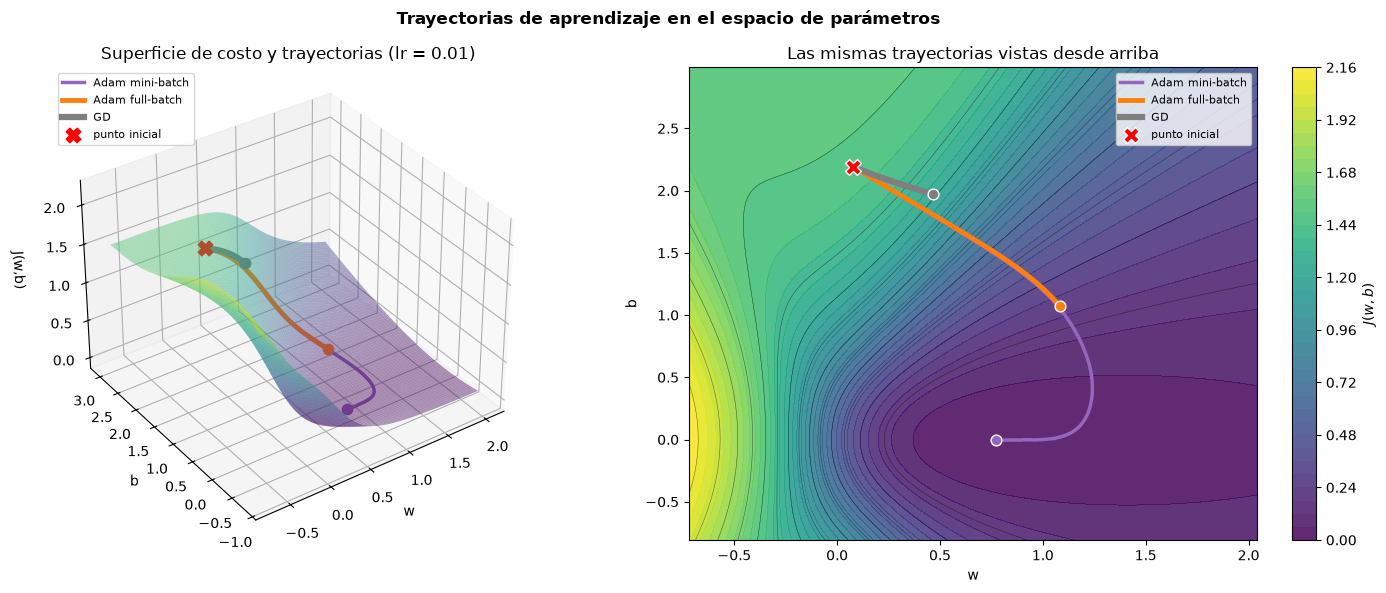

In [128]:
# ----------------------------------------------------------------------
# SUPERFICIE J(w,b) Y TRAYECTORIAS DE LOS 3 OPTIMIZADORES
# ----------------------------------------------------------------------
LR_3D = 0.01
trayectorias = {nombre: (hist[LR_3D][0], hist[LR_3D][1]) for nombre, hist in HISTORIALES.items()}

# Malla que cubre las tres trayectorias con margen
todos_w = np.concatenate([tw for tw, _ in trayectorias.values()])
todos_b = np.concatenate([tb for _, tb in trayectorias.values()])
rejilla_w = np.linspace(todos_w.min() - 0.8, todos_w.max() + 0.8, 160)
rejilla_b = np.linspace(todos_b.min() - 0.8, todos_b.max() + 0.8, 160)
WW, BB = np.meshgrid(rejilla_w, rejilla_b)
JJ = np.array([[costo(w, b) for w in rejilla_w] for b in rejilla_b])

fig = plt.figure(figsize=(15, 6))

# --- vista 3D ---
ax3d = fig.add_subplot(1, 2, 1, projection="3d")
ax3d.plot_surface(WW, BB, JJ, cmap="viridis", alpha=0.45, linewidth=0,
                  antialiased=True, rstride=2, cstride=2)
# Se dibujan de la trayectoria más larga a la más corta, con grosor creciente,
# para que las cortas no queden tapadas por las largas donde se superponen.
# Todas las curvas se levantan la MISMA cantidad sobre la superficie, así las tres
# arrancan dibujadas en el mismo punto. Lo que las separa visualmente es el grosor.
OFFSET = 0.02
orden_dibujo = sorted(trayectorias, key=lambda n: -np.sum(np.hypot(*map(np.diff, trayectorias[n]))))
for k, nombre in enumerate(orden_dibujo):
    t_w, t_b = trayectorias[nombre]
    t_J = np.array([costo(w, b) for w, b in zip(t_w, t_b)]) + OFFSET
    ax3d.plot(t_w, t_b, t_J, color=COL_OPT[nombre], lw=2.5 + k, label=nombre)
    ax3d.scatter([t_w[-1]], [t_b[-1]], [t_J[-1]], color=COL_OPT[nombre], s=55, depthshade=False)
ax3d.scatter([W0], [B0], [costo(W0, B0) + OFFSET], color="red", s=110, marker="X",
             depthshade=False, label="punto inicial")
ax3d.set_xlabel("w"); ax3d.set_ylabel("b"); ax3d.set_zlabel("J(w,b)", labelpad=8)
ax3d.view_init(elev=34, azim=-125)
ax3d.set_title(f"Superficie de costo y trayectorias (lr = {LR_3D})")
ax3d.legend(fontsize=8, loc="upper left")

# --- vista de contorno ---
ax2d = fig.add_subplot(1, 2, 2)
relleno = ax2d.contourf(WW, BB, JJ, levels=35, cmap="viridis", alpha=0.85)
ax2d.contour(WW, BB, JJ, levels=18, colors="k", linewidths=0.4, alpha=0.5)
plt.colorbar(relleno, ax=ax2d, label="$J(w,b)$")
for k, nombre in enumerate(orden_dibujo):
    t_w, t_b = trayectorias[nombre]
    ax2d.plot(t_w, t_b, color=COL_OPT[nombre], lw=2.5 + k, label=nombre)
    ax2d.scatter([t_w[-1]], [t_b[-1]], color=COL_OPT[nombre], s=60, zorder=5, edgecolor="w")
ax2d.scatter([W0], [B0], color="red", s=130, marker="X", zorder=6, edgecolor="w", label="punto inicial")
ax2d.set_xlabel("w"); ax2d.set_ylabel("b")
ax2d.set_title("Las mismas trayectorias vistas desde arriba")
ax2d.legend(fontsize=8)

fig.suptitle("Trayectorias de aprendizaje en el espacio de parámetros", fontweight="bold")
fig.tight_layout()
plt.show()

In [129]:
# ----------------------------------------------------------------------
# MEDIDAS DE LAS TRAYECTORIAS
# ----------------------------------------------------------------------
print(f"Trayectorias con lr = {LR_3D}, desde (w0, b0) = ({W0:.4f}, {B0:.4f})\n")
print(f"{'optimizador':<16} | {'camino':>7} | {'neto':>7} | {'camino/neto':>11} | {'w,b tras 10 épocas':>20} | {'w,b final':>16}")
print("-" * 98)
for nombre, (t_w, t_b) in trayectorias.items():
    camino = np.sum(np.hypot(np.diff(t_w), np.diff(t_b)))
    neto   = np.hypot(t_w[-1] - t_w[0], t_b[-1] - t_b[0])
    print(f"{nombre:<16} | {camino:>7.3f} | {neto:>7.3f} | {camino/neto:>11.3f} | "
          f"{t_w[10]:>9.3f}, {t_b[10]:>8.3f} | {t_w[-1]:>7.3f}, {t_b[-1]:>6.3f}")

w_min, b_min = WW.ravel()[JJ.argmin()], BB.ravel()[JJ.argmin()]
print(f"\nMínimo de la superficie sobre la malla: J = {JJ.min():.5f} en w = {w_min:.3f}, b = {b_min:.3f}")

# ¿Cada trayectoria se movió en la proporción que hacía falta?
print(f"\n{'':<18} | {'avance en w':>11} | {'avance en b':>11} | {'proporción b/w':>14}")
print("-" * 64)
print(f"{'lo que hacía falta':<18} | {w_min - W0:>+11.3f} | {b_min - B0:>+11.3f} | {abs((b_min-B0)/(w_min-W0)):>14.1f}")
for nombre, (t_w, t_b) in trayectorias.items():
    d_w, d_b = t_w[-1] - t_w[0], t_b[-1] - t_b[0]
    print(f"{nombre:<18} | {d_w:>+11.3f} | {d_b:>+11.3f} | {abs(d_b/d_w):>14.1f}")

g_w, g_b = gradiente(W0, B0)
print(f"\nGradiente en el arranque: |dJ/dw| = {abs(g_w):.4f}, |dJ/db| = {abs(g_b):.4f}"
      f"  -> localmente w baja el costo {abs(g_w)/abs(g_b):.2f} veces más rápido que b")

Trayectorias con lr = 0.01, desde (w0, b0) = (0.0794, 2.1902)

optimizador      |  camino |    neto | camino/neto |   w,b tras 10 épocas |        w,b final
--------------------------------------------------------------------------------------------------
GD               |   0.447 |   0.447 |       1.001 |     0.097,    2.178 |   0.468,  1.969
Adam full-batch  |   1.511 |   1.505 |       1.004 |     0.181,    2.089 |   1.084,  1.070
Adam mini-batch  |   2.957 |   2.299 |       1.286 |     1.071,    1.077 |   0.771, -0.002

Mínimo de la superficie sobre la malla: J = 0.00877 en w = 0.773, b = 0.005

                   | avance en w | avance en b | proporción b/w
----------------------------------------------------------------
lo que hacía falta |      +0.694 |      -2.185 |            3.2
GD                 |      +0.389 |      -0.221 |            0.6
Adam full-batch    |      +1.005 |      -1.120 |            1.1
Adam mini-batch    |      +0.692 |      -2.192 |            3.2

Gradient

#### Análisis de las trayectorias

Las tres arrancan en la misma cruz roja y salen para el mismo lado, $w$ creciendo y $b$ bajando, porque la dirección la marca el gradiente y en el arranque es el mismo para los tres. Lo que cambia es cuánto avanzan.

GD recorre 0.447 unidades en las 100 épocas y no sale de la zona de saturación. En el contorno es un segmento corto que apenas se despega del arranque, todavía en la zona verde. A las 10 épocas está en $(0.097,\ 2.178)$, donde empezó. Su camino y su desplazamiento neto dan lo mismo: va en línea recta.

Adam full-batch recorre 1.511 unidades, 3.4 veces más, con las mismas 100 correcciones y sobre la misma superficie. A las 10 épocas se movió 0.101 en $w$ y $-0.101$ en $b$, que es justo 10 correcciones de 0.01 en cada eje. También va casi recto, pero llega hasta el borde del valle.

Adam mini-batch es el único que dobla. Recorre 2.957 contra 2.299 de desplazamiento neto, un 29% más que la línea recta: baja en diagonal como los otros, se mete en la zona violeta y ahí gira siguiendo el fondo del valle hasta $(0.771,\ -0.002)$.

Lo que más me aclaró el gráfico fue comparar la dirección de cada uno con la que hacía falta. Desde el arranque hasta el mínimo hay que avanzar $+0.694$ en $w$ y bajar $-2.185$ en $b$: el viaje es mayormente bajar $b$, 3.2 a 1. Pero el gradiente en el arranque apunta más a $w$, 0.169 contra 0.117.

| | avance en w | avance en b | proporción b/w |
|---|---|---|---|
| lo que hacía falta | +0.694 | −2.185 | 3.2 |
| GD | +0.389 | −0.221 | 0.6 |
| Adam full-batch | +1.005 | −1.120 | 1.1 |
| Adam mini-batch | +0.692 | −2.192 | 3.2 |

GD sigue el gradiente local al pie de la letra y termina moviéndose casi el doble en $w$ que en $b$, la proporción opuesta a la que necesita. Adam full-batch va 1 a 1 por construcción, porque avanza el learning rate en cada eje: viaja en diagonal a 45 grados y termina en $(1.084,\ 1.070)$, ya pasado en $w$ con el $b$ todavía muy alto. El mini-batch clava la proporción, pero no porque sepa a dónde va: al hacer diez veces más correcciones alcanza a recorrer el tramo donde el gradiente deja de apuntar a $w$ y empieza a apuntar a $b$, y va reajustando sobre la marcha. Los otros dos se quedan en el primer tramo, donde el gradiente todavía engaña.

Eso reparte la dificultad de forma despareja. Los primeros dos tercios son una bajada donde lo único que importa es cuánto avanzás; el último tercio es un valle curvo donde importa hacia dónde vas, y solo el mini-batch llega hasta ahí.

### **RECOMENDACIÓN**:

Voy a valorar mucho que sus análisis, explicaciones y conclusiones sean bastante detalladas y con coherencia en los resultados obtenidos. Donde se evidencie un análisis propio de un humano estudiante de posgrado y no solo copiar y pegar lo que te dijo ChatGPT. Llevo ya años con esto, así que me daré cuenta rapidamente cuando sea así y cuando no.

Les recomiendo revisar el notebook sobre optimizadores que se encuentra en el repo. Pueden acceder mediante el siguiente [enlace](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_2026/CLASE%202/Notebooks/clase2_4_optimizadores.ipynb). En ese notebook vemos cómo aplicar GD y Adam full-batch para una red con relación lineal. Les servirá mucho como guía para realizar esta pregunta. Ahí también podrán ver cómo se hace una animación de un gráfico 3D.

Además, de igual forma tienen disponible el siguiente [material adicional del repo](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/tree/ap_2026/CLASE%202/Teoria/Material%20adicional), el cual le servirá para aplicar Adam, ya no solo en su versión full-batch, sino también en mini-batch

# PREGUNTA 2 (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

Descarga del dataset:  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- User_ID: Código identificador único del cliente que efectuó la compra.  
- Product_ID: Código identificador único del producto adquirido.  
- Age: Rango de edad del cliente.  
- Gender: Género del cliente (F: Femenino, M: Masculino).  
- Marital_Status: Estado civil del cliente (0: Soltero, 1: Casado).  
- City_Category: Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- Stay_In_Current_City_Years: Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- Product_Category: Categoría del producto comprado.  
- Product_Subcategory_1: Subcategoría principal del producto.  
- Product_Subcategory_2: Subcategoría secundaria del producto.  
- Purchase: Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un modelo predictivo capaz de estimar el gasto promedio que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual. Y la idea sería que una vez que el modelo ya esté listo y entrenado, se use para estimar apartir de datos de clientes relativamente nuevos, que solo llevan entre 3 a 5 visitas y compras en la tienda.

### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage, ocurre mucho cuando se usan proporciones como nuevas columnas**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


#### Respuesta 2.a

Antes de mirar una sola columna hay que decidir cuál es la unidad de análisis, porque de eso depende todo lo demás. El objetivo es predecir el gasto promedio de un cliente, no el monto de cada transacción. El dataset viene con una fila por transacción, así que la primera transformación es agregarlo a una fila por cliente:

- El target es el promedio de `Purchase` sobre todas las compras de ese cliente.
- Las features tienen que describir al cliente, no a una compra suya.

Sobre cuántas compras usar de cada cliente: uso todas. La aclaración de que el modelo se va a aplicar a clientes con 3 a 5 compras describe un escenario de uso futuro, no un recorte del dataset. Además el dataset no tiene ninguna columna de fecha, así que no hay forma de saber cuáles fueron las primeras compras de nadie ni de asumir que el orden de las filas es cronológico.

Lo que sí condiciona el diseño es que el modelo no debe apoyarse en cuántas compras acumuló el cliente. Si lo hiciera, aprendería de clientes con muchas transacciones (que son la mayoría acá) y fallaría con uno nuevo que tiene cinco. Eso descarta usar la cantidad de transacciones como feature, y más abajo verifico que también descarta varias features que parecen inocentes pero son la misma variable disfrazada.

In [130]:
# ----------------------------------------------------------------------
# DESCARGA Y CARGA DEL DATASET
# ----------------------------------------------------------------------
import os, sys, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ID_DRIVE = "1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ"

RUTA = next((p for p in ("dataset.csv", "data/dataset.csv") if os.path.exists(p)), None)
if RUTA is None:                                   # en Colab se descarga desde el link del enunciado
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown
    RUTA = "dataset.csv"
    gdown.download(id=ID_DRIVE, output=RUTA, quiet=True)

df = pd.read_csv(RUTA)
print(f"Archivo: {RUTA}   |   {df.shape[0]:,} transacciones x {df.shape[1]} columnas\n")

resumen = pd.DataFrame({
    "tipo":    df.dtypes.astype(str),
    "nulos":   df.isna().sum(),
    "% nulos": (100 * df.isna().mean()).round(1),
    "únicos":  df.nunique(),
})
print(resumen.to_string())
print(f"\nClientes distintos: {df.User_ID.nunique():,}")
print(f"Productos distintos: {df.Product_ID.nunique():,}")
print(f"Filas duplicadas exactas: {df.duplicated().sum():,} ({100*df.duplicated().mean():.1f}%)")

# ¿Cuánto cambiaría el target si se borraran los duplicados? Se afirma abajo, conviene medirlo.
target_con = df.groupby("User_ID").Purchase.mean()
target_sin = df.drop_duplicates().groupby("User_ID").Purchase.mean()
print(f"  si se borraran, el gasto promedio de cada cliente cambiaría "
      f"{(target_sin - target_con).abs().mean():.0f} en promedio, sobre una media de {target_con.mean():.0f}")

tx = df.groupby("User_ID").size()
print(f"\nTransacciones por cliente: min={tx.min()}  mediana={tx.median():.0f}  max={tx.max()}")
print(f"  clientes con 5 compras o menos: {(tx <= 5).sum()}")

Archivo: data/dataset.csv   |   182,721 transacciones x 11 columnas

                               tipo   nulos  % nulos  únicos
User_ID                       int64       0      0.0    7432
Product_ID                      str       0      0.0    2455
Age                             str       0      0.0       7
Gender                          str       0      0.0       2
Marital_Status                int64       0      0.0       2
City_Category                   str       0      0.0       3
Stay_In_Current_City_Years      str       0      0.0       5
Product_Category              int64       0      0.0      20
Product_Subcategory_1       float64   41818     22.9      33
Product_Subcategory_2       float64  105260     57.6      16
Purchase                      int64       0      0.0    1833

Clientes distintos: 7,432
Productos distintos: 2,455
Filas duplicadas exactas: 2,249 (1.2%)
  si se borraran, el gasto promedio de cada cliente cambiaría 50 en promedio, sobre una media de 6750

Tra

##### Qué se ve en la primera inspección

No hay nulos en ninguna columna salvo las dos subcategorías, y ahí el criterio es distinto para cada una.

`Product_Subcategory_1` tiene 22.9% de nulos y `Product_Subcategory_2` tiene 57.6%. La reacción automática sería dropear la segunda por tener más de la mitad vacía, pero en una columna categórica el nulo no siempre es un dato faltante. Acá lo más razonable es que signifique que ese producto no tiene una segunda subcategoría, que es información sobre el producto y no ausencia de información. Por eso no las dropeo ni las imputo: convierto el nulo en una categoría más. Imputar con la moda sería peor, porque inventaría una subcategoría que el producto no tiene.

Las 2.249 filas duplicadas exactas (1.2%) son el mismo cliente comprando el mismo producto al mismo precio. Sin una columna de fecha no hay forma de distinguir un error de carga de una compra repetida, así que tomé la decisión de no borrarlas. Se asume que son compras normales del mismo producto.

Un dato que condiciona el resto: el cliente con menos compras tiene 10 y la mediana es 18. O sea que en este dataset no hay ni un solo cliente con 5 compras o menos.

Precio promedio por categoría de producto:
                  count     mean     std
Product_Category                        
5                  8889    325.0   166.0
15                 6406    326.0   158.0
4                  7764    338.0   169.0
16                11783    916.0   934.0
17                13711    990.0  1010.0
10                14068    995.0  1011.0
2                  4032   1835.0   781.0
8                  8796   3758.0  2024.0
1                  6261   4897.0  1255.0
14                 6073   5491.0  1359.0
12                12294   7729.0  2779.0
11                11388   7743.0  2621.0
6                  6070   9665.0  1557.0
7                  5979   9670.0  1645.0
9                  7408   9856.0  1691.0
3                 19950  11748.0  9506.0
19                 7621  20931.0  5417.0
18                 7772  20975.0  4957.0
13                 7549  20985.0  5119.0
20                 8907  22033.0  5248.0

La categoría más cara vale 68 veces la más barata.

Ta

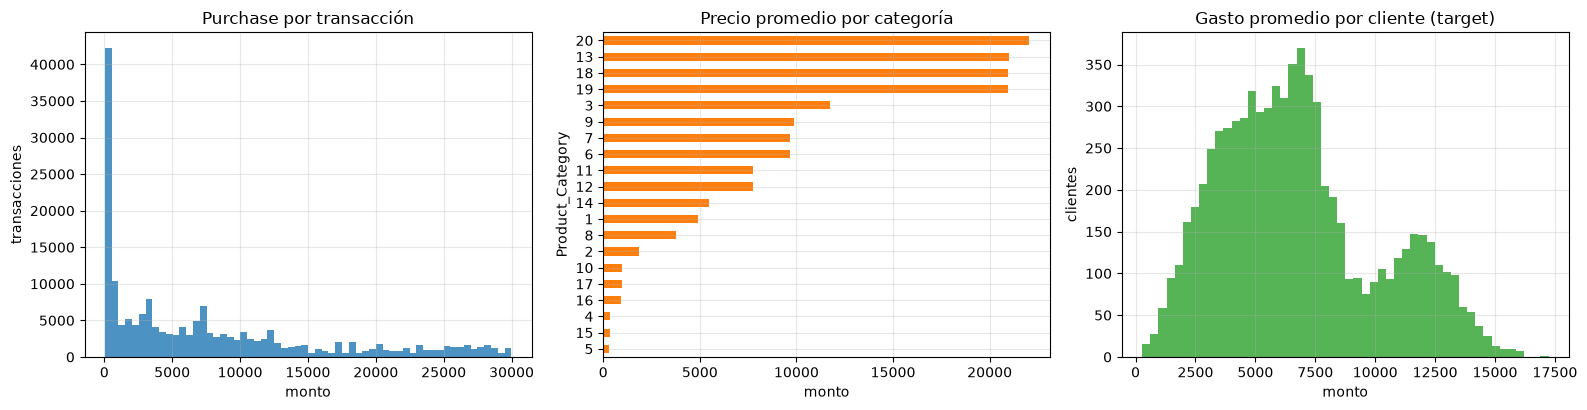

In [131]:
# ----------------------------------------------------------------------
# LA VARIABLE A PREDECIR Y DE QUÉ DEPENDE
# ----------------------------------------------------------------------
precio_cat = df.groupby("Product_Category").Purchase.agg(["count", "mean", "std"]).sort_values("mean")
print("Precio promedio por categoría de producto:")
print(precio_cat.round(0).to_string())
print(f"\nLa categoría más cara vale {precio_cat['mean'].max()/precio_cat['mean'].min():.0f} veces la más barata.")

gasto_promedio = df.groupby("User_ID").Purchase.mean().rename("gasto_promedio")
print(f"\nTarget (gasto promedio por cliente): media={gasto_promedio.mean():.0f}  "
      f"desvío={gasto_promedio.std():.0f}  rango=[{gasto_promedio.min():.0f}, {gasto_promedio.max():.0f}]")
print(f"  asimetría = {gasto_promedio.skew():.2f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].hist(df.Purchase, bins=60, color="tab:blue", alpha=.8)
ax[0].set_title("Purchase por transacción"); ax[0].set_xlabel("monto"); ax[0].set_ylabel("transacciones")
precio_cat["mean"].plot.barh(ax=ax[1], color="tab:orange")
ax[1].set_title("Precio promedio por categoría"); ax[1].set_xlabel("monto"); ax[1].set_ylabel("Product_Category")
ax[2].hist(gasto_promedio, bins=50, color="tab:green", alpha=.8)
ax[2].set_title("Gasto promedio por cliente (target)"); ax[2].set_xlabel("monto"); ax[2].set_ylabel("clientes")
for a in ax: a.grid(alpha=.3)
fig.tight_layout(); plt.show()

##### El hallazgo que define todo el feature engineering

La distribución de `Purchase` por transacción es fuertemente multimodal, y el gráfico del medio explica por qué: cada categoría de producto ocupa una banda de precios muy distinta. La más barata promedia 325 y la más cara 22.033, sesenta y ocho veces más. Los picos del primer histograma son directamente las categorías.

Eso significa que la categoría del producto es casi un proxy determinista de su precio. Y como el target es el promedio de los precios que pagó un cliente, si sé en qué proporción reparte sus compras entre las categorías, prácticamente sé cuánto gasta en promedio.

De ahí sale la feature principal: para cada cliente, qué proporción de sus compras cae en cada una de las 20 categorías. Son 20 columnas que suman 1. Y tienen dos propiedades importantes para este problema:

- Se construyen contando transacciones, sin tocar `Purchase` en ningún momento, así que no arrastran el target.
- Están normalizadas por la cantidad de compras del cliente, así que describen su perfil sin depender de cuántas compras tenga.

El histograma del target tiene dos modas, una alrededor de 6.500 y otra alrededor de 12.000. Eso es coherente con lo anterior: hay clientes que compran sobre todo en las categorías baratas y otros que compran en las caras, y el promedio de cada grupo cae en una moda distinta. No lo transformo, porque la asimetría es baja (0.54) y un log aplastaría justamente la separación entre los dos grupos, que es la señal que el modelo tiene que aprender.

Las cinco variables demográficas son constantes dentro de cada cliente: agregar con .first() no pierde nada.



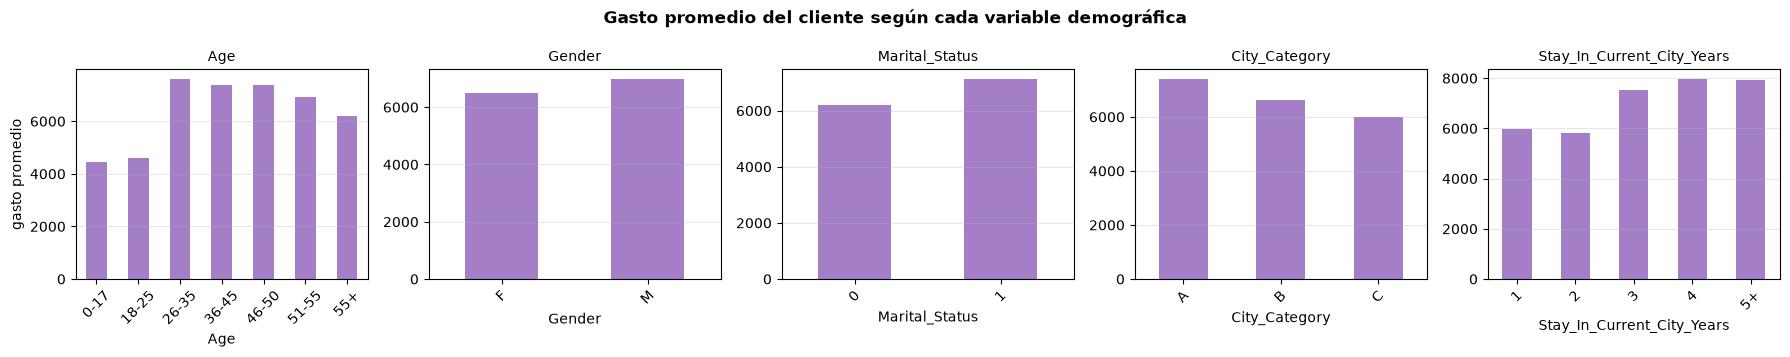

-- Age --
       count    mean
Age                 
0-17     545  4463.0
18-25    583  4616.0
26-35   1338  7594.0
36-45   1337  7385.0
46-50   1382  7370.0
51-55   1245  6913.0
55+     1002  6199.0

-- Gender --
        count    mean
Gender               
F        3531  6503.0
M        3901  6973.0

-- Marital_Status --
                count    mean
Marital_Status               
0                3022  6215.0
1                4410  7116.0

-- City_Category --
               count    mean
City_Category               
A               2883  7390.0
B               2514  6633.0
C               2035  5986.0

-- Stay_In_Current_City_Years --
                            count    mean
Stay_In_Current_City_Years               
1                            2102  5963.0
2                            2014  5822.0
3                            1017  7530.0
4                            1158  7956.0
5+                           1141  7917.0



In [132]:
# ----------------------------------------------------------------------
# LAS VARIABLES DEMOGRÁFICAS FRENTE AL TARGET
# ----------------------------------------------------------------------
demo = df.groupby("User_ID")[["Age", "Gender", "Marital_Status",
                              "City_Category", "Stay_In_Current_City_Years"]].first()

# ¿Son realmente constantes dentro de cada cliente? Si no lo fueran, agregar con .first() perdería información.
for col in demo.columns:
    n = df.groupby("User_ID")[col].nunique().max()
    assert n == 1, f"{col} cambia dentro de un mismo cliente"
print("Las cinco variables demográficas son constantes dentro de cada cliente: agregar con .first() no pierde nada.\n")

perfil = demo.join(gasto_promedio)
fig, ax = plt.subplots(1, 5, figsize=(18, 3.6))
for a, col in zip(ax, demo.columns):
    g = perfil.groupby(col).gasto_promedio.mean()
    g.plot.bar(ax=a, color="tab:purple", alpha=.85)
    a.set_title(col, fontsize=10); a.set_ylabel("gasto promedio" if col == "Age" else "")
    a.tick_params(axis="x", rotation=45); a.grid(alpha=.3, axis="y")
fig.suptitle("Gasto promedio del cliente según cada variable demográfica", fontweight="bold")
fig.tight_layout(); plt.show()

for col in demo.columns:
    g = perfil.groupby(col).gasto_promedio.agg(["count", "mean"]).round(0)
    print(f"-- {col} --"); print(g.to_string()); print()

##### Decisiones de encoding, una por una

El criterio que usé: una variable va a ordinal solo si tiene un orden natural y además su relación con el target respeta ese orden. Si tiene orden pero la relación no es monótona, el ordinal le impone al modelo una estructura falsa y conviene one-hot. Con dos categorías alcanza un mapping binario, porque el one-hot generaría una columna redundante.

`Age` → one-hot (7 columnas). Es la decisión menos obvia. Los rangos etarios tienen orden natural, así que el reflejo sería codificarlos 0 a 6. Pero la tabla muestra que el gasto sube de 4.463 en 0-17 hasta 7.594 en 26-35 y después baja hasta 6.199 en 55+. La relación es una joroba, no una recta. Con ordinal, el modelo tendría que gastar capacidad en reconstruir esa forma a partir de un solo número; con one-hot, cada rango recibe su propio nivel y no se le impone ninguna monotonía. Son solo 7 columnas, así que el costo es bajo.

`City_Category` → ordinal (C=0, B=1, A=2). Acá pasa lo contrario. El enunciado describe A como barrio de clase alta, B media y C media-baja, o sea que hay un orden declarado, y los datos lo respetan: 7.390, 6.633 y 5.986 de mayor a menor. Cuando el orden existe y la relación es monótona, el ordinal aporta esa información al modelo en una sola columna en vez de tres.

`Stay_In_Current_City_Years` → ordinal (mapping de `5+` a 5). Son años de antigüedad como cliente, con orden natural. La relación es creciente salvo un escalón entre 1 y 2 (5.963 y 5.822, prácticamente iguales), y después sube a 7.530, 7.956 y 7.917. El único trabajo extra es mapear el `5+` a un número para poder tratarla como numérica.

`Gender` → mapping binario (F=0, M=1). Dos categorías. One-hot daría dos columnas perfectamente complementarias, una de ellas redundante.

`Marital_Status` → se deja como está. Ya viene como 0/1, no necesita nada.

`Product_Category` → no se codifica como columna, se convierte en proporciones por cliente. Los números 1 a 20 son etiquetas sin orden, así que un label encoding sería un error grave: le diría al modelo que la categoría 20 es "más" que la 1 cuando son cosas distintas. Un one-hot a nivel transacción tampoco sirve, porque necesito una fila por cliente y no por compra. Las proporciones resuelven las dos cosas a la vez: son 20 columnas numéricas y ya están a nivel cliente.

`Product_Subcategory_1` y `Product_Subcategory_2` → proporciones por cliente, con el nulo como una categoría más. Mismo razonamiento que la categoría. El nulo entra como un valor propio en lugar de imputarse.

`Product_ID` → se descarta. 2.455 valores sin orden. Un one-hot agregaría 2.455 columnas casi vacías para 7.432 clientes, y la información de precio que aporta ya está capturada por la categoría, que es más gruesa pero mucho más estable.

`User_ID` → se descarta como feature. Es el identificador con el que agrupo; usarlo como variable sería memorizar clientes.

##### Las dos trampas de este dataset

Hay dos formas de arruinar este modelo y las dos son fáciles de cometer sin darse cuenta.

La primera es data leakage, y tiene dos niveles. El evidente es usar `Purchase` en alguna feature: el target es su promedio, así que cualquier estadístico suyo le entrega al modelo pedazos de la respuesta. El caso más claro es el gasto promedio del cliente por categoría, porque el target es justamente el promedio ponderado de esas columnas con las proporciones como pesos. La regla contra eso es simple y la sigo: ninguna feature toca `Purchase`, las proporciones cuentan transacciones y no montos.

El nivel menos evidente es que las proporciones se calculan sobre las mismas transacciones que se promedian para formar el target. Eso no viola la regla anterior y aun así hace que buena parte del $R^2$ sea aritmética en lugar de aprendizaje. Lo desarrollo con números en el punto 2.c, cuando ya haya un modelo con el que medirlo.

La segunda es depender de la cantidad de transacciones, que es lo que el enunciado pide evitar. No alcanza con no incluir esa columna: hay features que la reproducen casi exactamente sin nombrarla. La cantidad de categorías distintas que compra un cliente es la más tentadora de todas, y correlaciona 0.91 con la cantidad de transacciones, simplemente porque quien compra más veces toca más categorías. Lo mismo pasa con la cantidad de productos distintos y con los índices de concentración.

La celda siguiente mide las dos cosas antes de decidir el conjunto final de features.

In [133]:
# ----------------------------------------------------------------------
# VERIFICACIÓN DE LAS DOS TRAMPAS
# ----------------------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

prop_cat = pd.crosstab(df.User_ID, df.Product_Category, normalize="index").add_prefix("cat_")
demo_cod = pd.get_dummies(demo, drop_first=True).astype(float)
n_transacciones = df.groupby("User_ID").size()

def r2_rapido(X):
    """R2 de validación de una regresión lineal. Sirve para comparar bloques de features."""
    X = X.astype(float)
    Xtr, Xva, ytr, yva = train_test_split(X, gasto_promedio.loc[X.index], test_size=.2, random_state=42)
    return r2_score(yva, LinearRegression().fit(Xtr, ytr).predict(Xva))

# --- Trampa 1: features que tocan Purchase ---
gasto_medio_por_cat = df.pivot_table(index="User_ID", columns="Product_Category",
                                     values="Purchase", aggfunc="mean").add_prefix("gmedio_").fillna(0)
print("TRAMPA 1 - data leakage")
print(f"  limpio   (demográficas + proporciones de conteo)     R2 = {r2_rapido(demo_cod.join(prop_cat)):.4f}")
print(f"  CON FUGA (+ gasto promedio del cliente por categoría) R2 = {r2_rapido(demo_cod.join(prop_cat).join(gasto_medio_por_cat)):.4f}")
print("  -> esas columnas son los sumandos del propio target; el salto es el target filtrándose\n")

# --- Trampa 2: features que son la cantidad de transacciones disfrazada ---
candidatas = {
    "cantidad de transacciones":  n_transacciones,
    "categorías distintas":       df.groupby("User_ID").Product_Category.nunique(),
    "productos distintos":        df.groupby("User_ID").Product_ID.nunique(),
}
print("TRAMPA 2 - features que son la cantidad de transacciones con otro nombre")
print(f"  {'feature':30} | {'correlación con nº de transacciones':>36}")
print("  " + "-" * 69)
for nombre, serie in candidatas.items():
    r = np.corrcoef(serie.loc[n_transacciones.index], n_transacciones)[0, 1]
    print(f"  {nombre:30} | {r:>36.3f}")
r_props = [abs(np.corrcoef(prop_cat[c].loc[n_transacciones.index], n_transacciones)[0, 1]) for c in prop_cat]
print(f"  {'proporciones de categoría (20)':30} | {'máx ' + format(max(r_props), '.3f') + ', media ' + format(np.mean(r_props), '.3f'):>36}")

print("\n  Y el sesgo que introducirían es real:")
for lo, hi, etiqueta in [(10, 14, "pocas compras (10-14)"), (15, 25, "medias (15-25)"), (26, 50, "muchas (26-50)")]:
    m = (n_transacciones >= lo) & (n_transacciones <= hi)
    print(f"    {etiqueta:24} n={m.sum():5}   gasto promedio = {gasto_promedio[m.values].mean():.0f}")
print("  -> un modelo con esas features aprendería 'compra mucho = gasta mucho' y fallaría")
print("     con un cliente nuevo de 5 compras. Quedan todas afuera.")

TRAMPA 1 - data leakage
  limpio   (demográficas + proporciones de conteo)     R2 = 0.9375
  CON FUGA (+ gasto promedio del cliente por categoría) R2 = 0.9640
  -> esas columnas son los sumandos del propio target; el salto es el target filtrándose

TRAMPA 2 - features que son la cantidad de transacciones con otro nombre
  feature                        |  correlación con nº de transacciones
  ---------------------------------------------------------------------
  cantidad de transacciones      |                                1.000
  categorías distintas           |                                0.910
  productos distintos            |                                0.999
  proporciones de categoría (20) |               máx 0.389, media 0.220

  Y el sesgo que introducirían es real:
    pocas compras (10-14)    n= 2190   gasto promedio = 5047
    medias (15-25)           n= 2623   gasto promedio = 5159
    muchas (26-50)           n= 2619   gasto promedio = 9767
  -> un modelo con esa

In [134]:
# ----------------------------------------------------------------------
# DATASET FINAL: UNA FILA POR CLIENTE
# ----------------------------------------------------------------------
def construir_features(datos, columnas=None):
    """
    Perfil de cada cliente. Ninguna columna usa Purchase ni la cantidad de transacciones.

    `columnas` fija el esquema de salida. Es necesario para aplicar el modelo a clientes
    nuevos: crosstab y get_dummies solo emiten columnas para los valores presentes en los
    datos que reciben, así que un cliente con 5 compras generaría 15 columnas en vez de 82
    y el escalador fallaría. Con `columnas` se rellenan con cero las categorías que ese
    cliente no compró, que es justamente lo que significan.
    """
    dem = datos.groupby("User_ID")[["Age", "Gender", "Marital_Status",
                                    "City_Category", "Stay_In_Current_City_Years"]].first()
    X = pd.DataFrame(index=dem.index)

    # demográficas, cada una con el encoding que le corresponde
    X = X.join(pd.get_dummies(dem.Age, prefix="edad").astype(float))            # one-hot: relación no monótona
    X["genero_M"]   = (dem.Gender == "M").astype(float)                          # mapping binario
    X["casado"]     = dem.Marital_Status.astype(float)                           # ya era 0/1
    X["zona"]       = dem.City_Category.map({"C": 0, "B": 1, "A": 2}).astype(float)   # ordinal: orden declarado y monótono
    X["antiguedad"] = dem.Stay_In_Current_City_Years.str.replace("+", "", regex=False).astype(float)  # ordinal

    # patrones de compra: proporciones, que no dependen de cuántas compras tenga el cliente
    X = X.join(pd.crosstab(datos.User_ID, datos.Product_Category, normalize="index").add_prefix("cat_"))
    for col, pref in [("Product_Subcategory_1", "sub1_"), ("Product_Subcategory_2", "sub2_")]:
        sub = datos[col].fillna(-1).astype(int)          # el nulo entra como categoría propia
        X = X.join(pd.crosstab(datos.User_ID, sub, normalize="index").add_prefix(pref))
    X = X.astype(float)
    return X if columnas is None else X.reindex(columns=columnas, fill_value=0.0)

X_clientes = construir_features(df)
y_clientes = gasto_promedio.loc[X_clientes.index]

print(f"Dataset final: {X_clientes.shape[0]:,} clientes x {X_clientes.shape[1]} features")
bloques = {"demográficas": 11, "categoría": 20, "subcategoría 1": 34, "subcategoría 2": 17}
print("  " + " | ".join(f"{k}: {v}" for k, v in bloques.items()))
print(f"\nSin nulos: {X_clientes.isna().sum().sum() == 0}")

# Verificación de que ninguna feature depende del target: si reconstruyo todo con Purchase
# puesto en cero y sale idéntico, es porque la función nunca lo leyó.
df_sin_target = df.copy(); df_sin_target["Purchase"] = 0
assert construir_features(df_sin_target).equals(X_clientes), "alguna feature depende de Purchase"
print("Reconstruir las features con Purchase en cero da exactamente lo mismo -> ninguna usa el target")

print("\nAporte de cada bloque (R2 de validación con regresión lineal):")
sub1 = [c for c in X_clientes if c.startswith("sub1_")]
sub2 = [c for c in X_clientes if c.startswith("sub2_")]
cats = [c for c in X_clientes if c.startswith("cat_")]
demog = [c for c in X_clientes if c not in sub1 + sub2 + cats]
for etiqueta, cols in [(f"solo demográficas ({len(demog)})", demog),
                       (f"solo proporciones de categoría ({len(cats)})", cats),
                       (f"demográficas + categoría ({len(demog)+len(cats)})", demog + cats),
                       (f"todo, con subcategorías ({X_clientes.shape[1]})", list(X_clientes.columns))]:
    print(f"  {etiqueta:45} R2 = {r2_rapido(X_clientes[cols]):.4f}")

# El caso de uso del enunciado: un cliente nuevo del que solo se conocen 5 compras.
cliente_nuevo = df[df.User_ID == df.User_ID.iloc[0]].head(5)
print(f"\nCliente nuevo con 5 compras:")
print(f"  sin fijar el esquema: {construir_features(cliente_nuevo).shape[1]} columnas (no sirve)")
X_nuevo = construir_features(cliente_nuevo, columnas=X_clientes.columns)
print(f"  fijando el esquema:   {X_nuevo.shape[1]} columnas, listo para el modelo")

# --- Cómo quedó el dataset ---
preview = X_clientes.copy()
preview.insert(0, "gasto_promedio", y_clientes)
cols_muestra = (["gasto_promedio", "edad_26-35", "genero_M", "casado", "zona", "antiguedad"]
                + [c for c in X_clientes if c.startswith("cat_")][:4]
                + ["sub1_-1", "sub2_-1"])
print("\nPrimeras 6 filas (una por cliente, columnas de muestra):")
print(preview[cols_muestra].head(6).round(3).to_string())

print(f"\nResumen de las 82 features:")
print(preview[cols_muestra[1:]].describe().loc[["mean", "std", "min", "max"]].round(3).to_string())

print(f"\nLas proporciones de cada bloque suman 1 en cada fila:")
for pref, nombre in [("cat_", "categoría"), ("sub1_", "subcategoría 1"), ("sub2_", "subcategoría 2")]:
    sumas = X_clientes[[c for c in X_clientes if c.startswith(pref)]].sum(axis=1)
    print(f"  {nombre:16} suma mínima = {sumas.min():.4f}   suma máxima = {sumas.max():.4f}")

X_clientes.assign(gasto_promedio=y_clientes).to_csv("dataset_por_cliente.csv")
print(f"\nGuardado en dataset_por_cliente.csv por si se quiere revisar completo.")

Dataset final: 7,432 clientes x 82 features
  demográficas: 11 | categoría: 20 | subcategoría 1: 34 | subcategoría 2: 17

Sin nulos: True
Reconstruir las features con Purchase en cero da exactamente lo mismo -> ninguna usa el target

Aporte de cada bloque (R2 de validación con regresión lineal):
  solo demográficas (11)                        R2 = 0.3177
  solo proporciones de categoría (20)           R2 = 0.9378
  demográficas + categoría (31)                 R2 = 0.9376
  todo, con subcategorías (82)                  R2 = 0.9422

Cliente nuevo con 5 compras:
  sin fijar el esquema: 15 columnas (no sirve)
  fijando el esquema:   82 columnas, listo para el modelo

Primeras 6 filas (una por cliente, columnas de muestra):
         gasto_promedio  edad_26-35  genero_M  casado  zona  antiguedad  cat_1  cat_2  cat_3  cat_4  sub1_-1  sub2_-1
User_ID                                                                                                              
1000035        1912.923         0.

##### Conclusiones preliminares del EDA

El perfil de compra explica casi todo y la demografía casi nada. Las cinco variables demográficas juntas llegan a un R² de 0.32. Las 20 proporciones de categoría solas llegan a 0.94, y agregarles la demografía encima no mejora nada. No es que la demografía no sirva: es que lo que aporta ya está contenido en qué compra la persona. Un cliente de 26-35 de zona A compra categorías caras, y una vez que sé qué compra, saber su edad no agrega información. Las dejo igual porque el objetivo del caso las pide explícitamente y porque para un cliente nuevo con pocas compras, donde las proporciones son estimaciones ruidosas, son el único apoyo estable que queda.

Las subcategorías aportan poco pero aportan. Pasar de 31 a 82 features sube el R² de 0.9376 a 0.9422. Es una mejora chica, dentro del ruido de un solo split, pero consistente. Las dejo porque el modelo va a tener regularización y porque el costo de 51 columnas más es bajo con 7.432 filas.

Agrupar en 20 categorías tiene un costo. Dos clientes con el mismo perfil de categorías van a tener promedios distintos según qué productos particulares compraron dentro de cada una, y esa diferencia el modelo no la puede ver. No es ruido del dato, es información que descarto al elegir la categoría como descripción del producto. Lo cuantifico en el punto 2.c, donde resulta ser más grande de lo que esperaba.

Lo que dejé afuera importa, aunque menos de lo que parece. Cuatro features que sonaban razonables (cantidad de categorías, de productos, concentración, y la cantidad de transacciones) quedaron descartadas por correlacionar entre 0.67 y 0.999 con el volumen de compras. Pero hay que ser honesto con el alcance de esa decisión: las 20 proporciones que sí conservo permiten reconstruir varias de ellas. La cantidad de categorías distintas es exactamente `(proporciones > 0).sum()`, y el índice de concentración es la suma de sus cuadrados. Descartarlas evita dárselas servidas al modelo, no le impide derivarlas.

### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

#### Respuesta 2.b

El modelo es un perceptrón multicapa de tres capas ocultas con activación en cada una. Antes de elegir los hiperparámetros por prueba y error, las decisiones que tienen una razón teórica clara:

Función de costo: MSE. El target es continuo y lo que pide el caso es el gasto *promedio*, y minimizar el error cuadrático medio es exactamente estimar la media condicional. Si usara MAE estaría estimando la mediana, que no es lo que se pide. Además el $R^2$ con el que se evalúa es una reescala del MSE, así que entreno optimizando la misma cantidad que después mido, sin desalineación entre una cosa y la otra.

Optimizador: Adam. En el punto 1 vimos que su ventaja es que el tamaño del avance lo fija el learning rate y no la magnitud del gradiente, lo que lo hace mucho menos sensible a arrancar en una zona de gradiente chico. Con 82 features en escalas distintas eso importa: las proporciones viven entre 0 y 1 mientras que `zona` toma valores 0, 1 o 2 y `antiguedad` de 1 a 5, y aunque las estandarizo, las columnas de categorías raras quedan muy dispersas. El learning rate lo elijo empíricamente más abajo.

Activación: ReLU. Es la elección por defecto para capas ocultas y la razón conecta directamente con el punto 1. La `tanh` satura: cuando la entrada se aleja de cero su derivada tiende a cero y el gradiente se apaga, que es exactamente el problema que estudiamos en 1.a. Con tres capas apiladas ese factor se multiplica tres veces. ReLU tiene derivada 1 en todo el semieje positivo, así que no atenúa el gradiente en la vuelta. Igual lo verifico empíricamente contra otras tres.

Escalado de las features. Ajustado solamente sobre el conjunto de entrenamiento. Si calculara la media y el desvío sobre todo el dataset, los datos de validación estarían influyendo en la transformación y sería otra forma de leakage, más sutil que la de las features pero del mismo tipo.

Escalado del target. También lo estandarizo. No cambia el $R^2$, que es invariante a la escala, pero deja los errores en un rango donde el learning rate por defecto de Adam funciona sin ajustes raros.

Regularización. El EDA mostró que el problema es casi lineal, así que una red de tres capas tiene capacidad de sobra y el riesgo real es el sobreajuste, no la falta de capacidad. Cuánta y de qué tipo lo decido probando.

In [135]:
# ----------------------------------------------------------------------
# SEPARACIÓN Y ESCALADO
# ----------------------------------------------------------------------
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

SEMILLA = 42
torch.manual_seed(SEMILLA)
np.random.seed(SEMILLA)

# La separación es por cliente, que es la unidad de análisis: ningún cliente
# aparece en train y en validación a la vez.
X_tr, X_va, y_tr, y_va = train_test_split(X_clientes, y_clientes, test_size=0.2, random_state=SEMILLA)

esc_X = StandardScaler().fit(X_tr)                       # ajustado SOLO con train
esc_y = StandardScaler().fit(y_tr.values.reshape(-1, 1))

Xtr = torch.tensor(esc_X.transform(X_tr), dtype=torch.float32)
Xva = torch.tensor(esc_X.transform(X_va), dtype=torch.float32)
ytr = torch.tensor(esc_y.transform(y_tr.values.reshape(-1, 1)).ravel(), dtype=torch.float32)
yva = torch.tensor(esc_y.transform(y_va.values.reshape(-1, 1)).ravel(), dtype=torch.float32)

print(f"train      {len(Xtr):,} clientes")
print(f"validación {len(Xva):,} clientes")
print(f"features   {Xtr.shape[1]}")
print(f"\ngasto promedio en train      = {y_tr.mean():.0f}")
print(f"gasto promedio en validación = {y_va.mean():.0f}   (los dos grupos son comparables)")

train      5,945 clientes
validación 1,487 clientes
features   82

gasto promedio en train      = 6775
gasto promedio en validación = 6650   (los dos grupos son comparables)


In [136]:
# ----------------------------------------------------------------------
# EL MODELO Y EL BUCLE DE ENTRENAMIENTO
# ----------------------------------------------------------------------
class MLP(nn.Module):
    """Perceptrón multicapa: una capa lineal + activación (+ dropout) por cada capa oculta."""
    def __init__(self, n_entradas, capas=(128, 64, 32), activacion=nn.ReLU, p_dropout=0.0):
        super().__init__()
        bloques, previa = [], n_entradas
        for n in capas:
            bloques += [nn.Linear(previa, n), activacion()]
            if p_dropout > 0:
                bloques.append(nn.Dropout(p_dropout))
            previa = n
        bloques.append(nn.Linear(previa, 1))              # salida: un número, sin activación
        self.red = nn.Sequential(*bloques)

    def forward(self, x):
        return self.red(x).squeeze(-1)


def entrenar(capas=(128, 64, 32), activacion=nn.ReLU, p_dropout=0.0, lr=1e-3,
             weight_decay=0.0, epocas=100, batch=128, semilla=SEMILLA, optimizador="adam"):
    """Entrena y devuelve el historial por época: (loss train, loss val, R2 train, R2 val)."""
    torch.manual_seed(semilla)
    modelo = MLP(Xtr.shape[1], capas, activacion, p_dropout)
    opt = {"adam": torch.optim.Adam, "sgd": torch.optim.SGD}[optimizador](
        modelo.parameters(), lr=lr, weight_decay=weight_decay)
    criterio = nn.MSELoss()
    cargador = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xtr, ytr), batch_size=batch, shuffle=True)

    historial, mejor_r2, mejor_estado, mejor_epoca = [], -np.inf, None, 0
    for epoca in range(1, epocas + 1):
        modelo.train()
        for xb, yb in cargador:
            opt.zero_grad()
            criterio(modelo(xb), yb).backward()
            opt.step()

        modelo.eval()
        with torch.no_grad():
            p_tr, p_va = modelo(Xtr), modelo(Xva)
            historial.append((criterio(p_tr, ytr).item(), criterio(p_va, yva).item(),
                              r2_score(ytr, p_tr), r2_score(yva, p_va)))
        if historial[-1][3] > mejor_r2:                    # se guarda el mejor estado visto
            mejor_r2, mejor_epoca = historial[-1][3], epoca
            mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}

    modelo.load_state_dict(mejor_estado)                   # early stopping con restauración
    return modelo, np.array(historial), mejor_epoca

print("Modelo de ejemplo:")
print(MLP(Xtr.shape[1]))
print(f"\nParámetros entrenables: {sum(p.numel() for p in MLP(Xtr.shape[1]).parameters()):,}")

Modelo de ejemplo:
MLP(
  (red): Sequential(
    (0): Linear(in_features=82, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros entrenables: 20,993


In [137]:
# ----------------------------------------------------------------------
# ELECCIÓN EMPÍRICA DE LOS HIPERPARÁMETROS
# ----------------------------------------------------------------------
# Cada configuración se corre con 3 semillas y se informa el promedio, porque con una
# sola semilla las diferencias quedan tapadas por el ruido del entrenamiento.
import time
SEMILLAS = (0, 1, 2)

def probar(titulo, opciones, epocas, **fijos):
    print(f"--- {titulo} ---")
    for etiqueta, kw in opciones.items():
        res = [entrenar(epocas=epocas, semilla=s, **{**fijos, **kw}) for s in SEMILLAS]
        picos   = [h[:, 3].max() for _, h, _ in res]
        epocas_ = [ep for _, _, ep in res]
        # la brecha se mide en la MISMA época que el R2 informado, no en la última:
        # son dos modelos distintos y el que se conserva es el de la mejor época
        brechas = [h[ep - 1, 2] - h[ep - 1, 3] for _, h, ep in res]
        print(f"  {etiqueta:22} R2 val = {np.mean(picos):.4f} ± {np.std(picos):.4f}   "
              f"mejor época ≈ {np.mean(epocas_):3.0f}   brecha train-val = {np.mean(brechas):+.4f}")
    print()

t0 = time.time()

# --- Etapa 1: regularización, que es lo que más pesa ---
probar("ETAPA 1 - weight decay (128-64-32, ReLU, Adam lr=3e-4)",
       {f"weight_decay = {wd}": dict(weight_decay=wd) for wd in (0.0, 1e-3, 1e-2, 1e-1)},
       epocas=100, lr=3e-4)

# --- Etapa 2: el resto, ya con la regularización elegida ---
REG = dict(weight_decay=1e-2)

probar("ETAPA 2 - learning rate (ReLU)",
       {f"lr = {lr}": dict(lr=lr) for lr in (3e-3, 1e-3, 3e-4, 1e-4)},
       epocas=150, **REG)

probar("ETAPA 2 - arquitectura (ReLU, lr=3e-4)",
       {str(c): dict(capas=c) for c in [(32, 32, 32), (64, 32, 32), (128, 64, 32)]},
       epocas=150, lr=3e-4, **REG)

# El enunciado marca el dropout como opcional: acá se ve si agrega algo sobre el weight decay
probar("ETAPA 2 - dropout, que el enunciado deja opcional (ReLU, lr=3e-4)",
       {f"dropout = {p}": dict(p_dropout=p) for p in (0.0, 0.2)},
       epocas=150, lr=3e-4, **REG)

print(f"(el barrido completo tardó {time.time()-t0:.0f} segundos)")

--- ETAPA 1 - weight decay (128-64-32, ReLU, Adam lr=3e-4) ---
  weight_decay = 0.0     R2 val = 0.9365 ± 0.0004   mejor época ≈  15   brecha train-val = +0.0256
  weight_decay = 0.001   R2 val = 0.9376 ± 0.0004   mejor época ≈  18   brecha train-val = +0.0271
  weight_decay = 0.01    R2 val = 0.9431 ± 0.0005   mejor época ≈  24   brecha train-val = +0.0192
  weight_decay = 0.1     R2 val = 0.9298 ± 0.0004   mejor época ≈  66   brecha train-val = +0.0075

--- ETAPA 2 - learning rate (ReLU) ---
  lr = 0.003             R2 val = 0.9404 ± 0.0011   mejor época ≈  97   brecha train-val = +0.0189
  lr = 0.001             R2 val = 0.9425 ± 0.0004   mejor época ≈  13   brecha train-val = +0.0162
  lr = 0.0003            R2 val = 0.9431 ± 0.0005   mejor época ≈  24   brecha train-val = +0.0192
  lr = 0.0001            R2 val = 0.9430 ± 0.0003   mejor época ≈  71   brecha train-val = +0.0223

--- ETAPA 2 - arquitectura (ReLU, lr=3e-4) ---
  (32, 32, 32)           R2 val = 0.9433 ± 0.0001   mejor

##### Qué dicen las pruebas

El barrido va en dos etapas: primero la regularización y después el resto con esa regularización ya puesta. Comparar learning rates o arquitecturas sin regularizar mide cuál sobreajusta más lento, no cuál funciona mejor.

Weight decay. Es lo que más mueve el resultado: 0.9365 sin nada, 0.9431 con 0.01, y 0.9298 con 0.1, que ya es demasiado. Hay un óptimo claro y no es un empate. Confirma lo del EDA: la red tiene capacidad de sobra para un problema casi lineal, y lo único que hace con el exceso es memorizar.

Learning rate. 3e-4 da 0.9431 y 1e-4 queda en 0.9430, o sea iguales; 1e-3 baja a 0.9425 y 3e-3 a 0.9404. Elijo 3e-4.

Arquitectura. Las tres opciones caen entre 0.9431 y 0.9434, o sea nada. Elijo 128-64-32, que cumple el mínimo de tres capas ocultas y 32 neuronas por capa.

Dropout. El enunciado lo deja opcional y lo probé para decidir con datos: sobre el weight decay agrega 0.9433 contra 0.9431, dentro del ruido. Cierra un poco la brecha entre train y validación, de +0.019 a +0.018, pero no mejora el resultado. Lo dejo afuera, porque la regularización que hace falta ya la da el weight decay.

Épocas. No la fijo a ojo: entreno 150 guardando el estado con mejor $R^2$ de validación y restauro ese al terminar. Con esta configuración cae alrededor de la época 20.

La activación es lo único que no barrí, y la justifico por teoría, que es una de las dos formas que admite el enunciado. Uso ReLU porque es la única candidata que no atenúa el gradiente: su derivada vale 1 en todo el semieje positivo, mientras que la `tanh` satura igual que vimos en el punto 1, y con tres capas ese factor se multiplicaría tres veces.

Una advertencia para todo el barrido: el $\pm$ mide dispersión entre semillas con el mismo split, y la variabilidad entre splits distintos es mayor. Diferencias de una o dos milésimas no son un ranking.

Configuración final: tres capas ocultas de 128, 64 y 32 neuronas con ReLU, MSE como costo, Adam con learning rate 3e-4 y weight decay 0.01, batches de 128 y 150 épocas con early stopping.

In [138]:
# ----------------------------------------------------------------------
# ENTRENAMIENTO DEL MODELO FINAL
# ----------------------------------------------------------------------
CONFIG = dict(capas=(128, 64, 32), activacion=nn.ReLU,
              lr=3e-4, weight_decay=1e-2, epocas=150, batch=128)

modelo, historial, mejor_epoca = entrenar(**CONFIG)

print("Configuración final:")
for k, v in CONFIG.items():
    print(f"  {k:15} {getattr(v, '__name__', v)}")

print(f"\nMejor época: {mejor_epoca} de {CONFIG['epocas']} (se restauran los pesos de esa época)")
print(f"  R2 validación = {historial[mejor_epoca-1, 3]:.4f}")
print(f"  R2 train      = {historial[mejor_epoca-1, 2]:.4f}")
print(f"  brecha        = {historial[mejor_epoca-1, 2] - historial[mejor_epoca-1, 3]:+.4f}")

Configuración final:
  capas           (128, 64, 32)
  activacion      ReLU
  lr              0.0003
  weight_decay    0.01
  epocas          150
  batch           128

Mejor época: 20 de 150 (se restauran los pesos de esa época)
  R2 validación = 0.9435
  R2 train      = 0.9616
  brecha        = +0.0181


### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

#### Respuesta 2.c

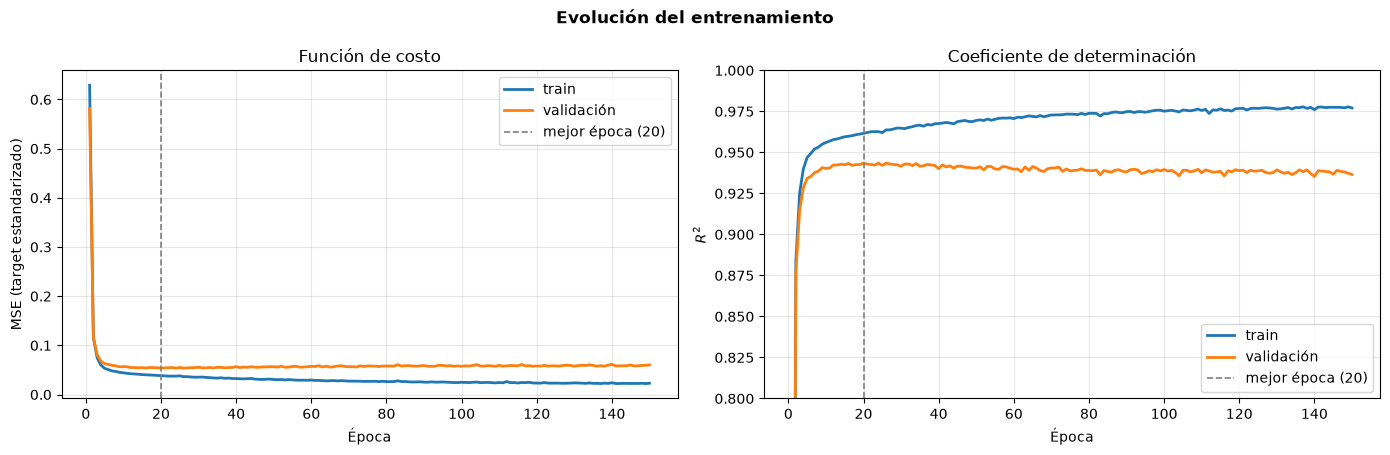

  época |  MSE train |    MSE val |  R2 train |    R2 val
----------------------------------------------------------
      1 |     0.6289 |     0.5817 |    0.3711 |    0.3871
     10 |     0.0440 |     0.0568 |    0.9560 |    0.9402
     25 |     0.0379 |     0.0550 |    0.9621 |    0.9420
     50 |     0.0305 |     0.0565 |    0.9695 |    0.9405
     20 |     0.0384 |     0.0537 |    0.9616 |    0.9435  <- mejor
    150 |     0.0230 |     0.0602 |    0.9770 |    0.9365


In [139]:
# ----------------------------------------------------------------------
# EVOLUCIÓN POR ÉPOCA DEL COSTO Y DEL R2
# ----------------------------------------------------------------------
epocas = np.arange(1, len(historial) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].plot(epocas, historial[:, 0], color="tab:blue", lw=2, label="train")
ax[0].plot(epocas, historial[:, 1], color="tab:orange", lw=2, label="validación")
ax[0].set_ylabel("MSE (target estandarizado)"); ax[0].set_title("Función de costo")

ax[1].plot(epocas, historial[:, 2], color="tab:blue", lw=2, label="train")
ax[1].plot(epocas, historial[:, 3], color="tab:orange", lw=2, label="validación")
ax[1].set_ylabel("$R^2$"); ax[1].set_title("Coeficiente de determinación")
ax[1].set_ylim(0.80, 1.0)

for a in ax:
    a.axvline(mejor_epoca, color="gray", ls="--", lw=1.2, label=f"mejor época ({mejor_epoca})")
    a.set_xlabel("Época"); a.grid(alpha=.3); a.legend()

fig.suptitle("Evolución del entrenamiento", fontweight="bold")
fig.tight_layout(); plt.show()

print(f"{'época':>7} | {'MSE train':>10} | {'MSE val':>10} | {'R2 train':>9} | {'R2 val':>9}")
print("-" * 58)
for e in [1, 10, 25, 50, mejor_epoca, 150]:
    f = historial[e-1]
    marca = "  <- mejor" if e == mejor_epoca else ""
    print(f"{e:>7} | {f[0]:>10.4f} | {f[1]:>10.4f} | {f[2]:>9.4f} | {f[3]:>9.4f}{marca}")

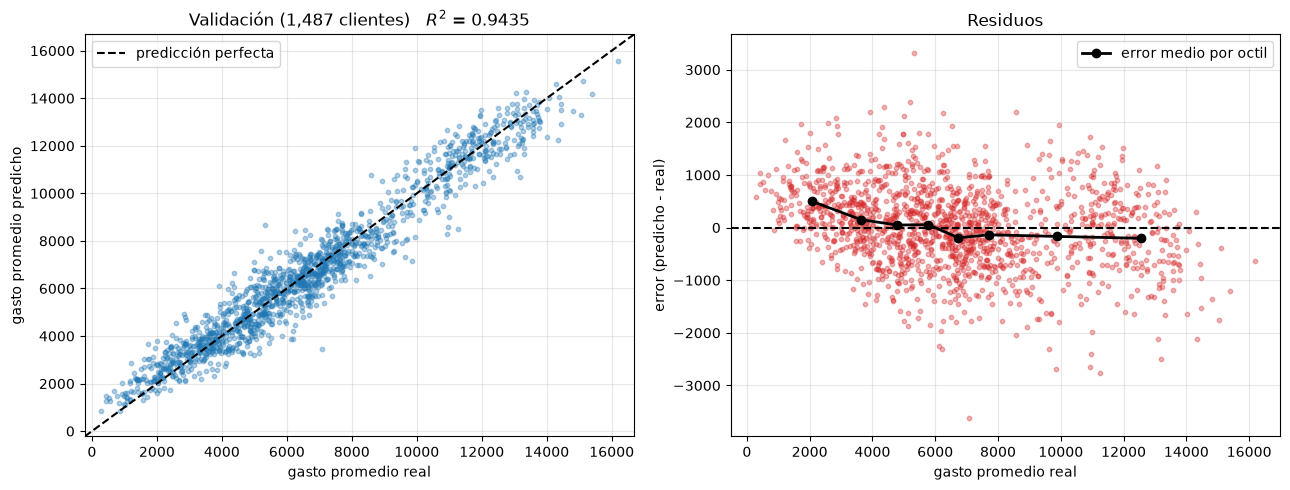

R2   = 0.9435
Pendiente de predicho vs real = 0.9392  (1.0 sería sin encogimiento hacia la media)
RMSE = 768   sobre un gasto promedio de 6650
MAE  = 597   (12.5% de error relativo medio)

Errores por tramo de gasto real:
        clientes   gasto_medio  error_absoluto  error_relativo       sesgo
tramo                                                                     
<4k          337   2729.000000      528.400024            25.0  351.500000
4k-7k        557   5580.700195      608.099976            11.3   -9.500000
7k-10k       319   8098.100098      608.700012             7.5 -211.800003
>10k         274  11960.200195      647.799988             5.4 -130.100006


In [140]:
# ----------------------------------------------------------------------
# REAL VS PREDICHO EN VALIDACIÓN
# ----------------------------------------------------------------------
modelo.eval()
with torch.no_grad():
    pred_va = modelo(Xva).numpy()

# se deshace el escalado para volver a pesos
real  = esc_y.inverse_transform(yva.numpy().reshape(-1, 1)).ravel()
predi = esc_y.inverse_transform(pred_va.reshape(-1, 1)).ravel()
error = predi - real

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
lim = [min(real.min(), predi.min()) - 500, max(real.max(), predi.max()) + 500]
ax[0].scatter(real, predi, s=10, alpha=.35, color="tab:blue")
ax[0].plot(lim, lim, "k--", lw=1.5, label="predicción perfecta")
ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("gasto promedio real"); ax[0].set_ylabel("gasto promedio predicho")
ax[0].set_title(f"Validación ({len(real):,} clientes)   $R^2$ = {r2_score(real, predi):.4f}")
ax[0].legend()

# Los residuos van contra el valor REAL: contra el predicho, el encogimiento hacia la
# media queda invisible por construcción.
ax[1].scatter(real, error, s=10, alpha=.35, color="tab:red")
ax[1].axhline(0, color="k", ls="--", lw=1.5)
octiles = pd.qcut(real, 8, labels=False)
medias = pd.Series(error).groupby(octiles).mean()
centros = pd.Series(real).groupby(octiles).mean()
ax[1].plot(centros, medias, "o-", color="k", lw=2, ms=6, label="error medio por octil")
ax[1].set_xlabel("gasto promedio real"); ax[1].set_ylabel("error (predicho - real)")
ax[1].set_title("Residuos"); ax[1].legend()
for a in ax: a.grid(alpha=.3)
fig.tight_layout(); plt.show()

pendiente = np.polyfit(real, predi, 1)[0]
print(f"R2   = {r2_score(real, predi):.4f}")
print(f"Pendiente de predicho vs real = {pendiente:.4f}  (1.0 sería sin encogimiento hacia la media)")
print(f"RMSE = {np.sqrt(np.mean(error**2)):.0f}   sobre un gasto promedio de {real.mean():.0f}")
print(f"MAE  = {np.mean(np.abs(error)):.0f}   ({100*np.mean(np.abs(error)/real):.1f}% de error relativo medio)")
print(f"\nErrores por tramo de gasto real:")
tramos = pd.cut(real, [0, 4000, 7000, 10000, 20000], labels=["<4k", "4k-7k", "7k-10k", ">10k"])
tabla = pd.DataFrame({"real": real, "error_abs": np.abs(error), "tramo": tramos})
tabla["error_con_signo"] = error
tabla["error_rel"] = 100 * tabla.error_abs / tabla.real
print(tabla.groupby("tramo", observed=True)
           .agg(clientes=("real", "size"), gasto_medio=("real", "mean"),
                error_absoluto=("error_abs", "mean"), error_relativo=("error_rel", "mean"),
                sesgo=("error_con_signo", "mean"))
           .round(1).to_string())

In [141]:
# ----------------------------------------------------------------------
# CONTRA QUÉ SE COMPARA
# ----------------------------------------------------------------------
from sklearn.ensemble import HistGradientBoostingRegressor

X_tr_esc, X_va_esc = esc_X.transform(X_tr), esc_X.transform(X_va)
lineal = LinearRegression().fit(X_tr_esc, y_tr)
gbm    = HistGradientBoostingRegressor(random_state=SEMILLA).fit(X_tr_esc, y_tr)

# Baseline sin un solo parámetro ajustado: el promedio de cada cliente estimado como
# la suma de sus proporciones por el precio medio de cada categoría. Es una tabla de
# 20 números calculada sobre train, sin entrenamiento de ningún tipo.
precio_medio_cat = df[df.User_ID.isin(X_tr.index)].groupby("Product_Category").Purchase.mean()
prop_val = pd.crosstab(df.User_ID, df.Product_Category, normalize="index").loc[X_va.index]
pred_aritmetica = prop_val.mul(precio_medio_cat.reindex(prop_val.columns), axis=1).sum(axis=1)

# El MLP en su última época, sin elegir checkpoint mirando validación
modelo_final_epoca, hist2, _ = entrenar(**CONFIG)
with torch.no_grad():
    r2_ultima = r2_score(yva, modelo_final_epoca(Xva))

print(f"{'modelo':46} {'R2 validación':>14}")
print("-" * 62)
print(f"{'predecir siempre la media':46} {0.0:>14.4f}")
print(f"{'aritmética pura: proporciones x precio medio':46} {r2_score(y_va, pred_aritmetica):>14.4f}")
print(f"{'gradient boosting (hiperparámetros por defecto)':46} {r2_score(y_va, gbm.predict(X_va_esc)):>14.4f}")
print(f"{'regresión lineal':46} {r2_score(y_va, lineal.predict(X_va_esc)):>14.4f}")
print(f"{'MLP, última época':46} {hist2[-1, 3]:>14.4f}")
print(f"{'MLP, mejor época elegida en validación':46} {r2_score(real, predi):>14.4f}")
print(f"\nElegir la mejor época mirando validación vale {r2_score(real, predi) - hist2[-1, 3]:+.4f}, "
      f"y el margen del MLP\nsobre la regresión lineal es {r2_score(real, predi) - r2_score(y_va, lineal.predict(X_va_esc)):+.4f}: "
      f"la ventaja está dentro de lo que aporta esa elección.")

# ----------------------------------------------------------------------
# ¿HAY UN TECHO? DEPENDE DE CON QUÉ SE DESCRIBA UN PRODUCTO
# ----------------------------------------------------------------------
precios_por_producto = df.groupby("Product_ID").Purchase.nunique()
print(f"\nPrecios distintos por producto: min={precios_por_producto.min()}, max={precios_por_producto.max()}")
print("  -> cada producto tiene un precio único, así que el gasto promedio de un cliente es")
print("     una suma ponderada EXACTA de precios. No hay ruido irreducible en este problema.\n")

df["celda_producto"] = (df.Product_Category.astype(str) + "|"
                        + df.Product_Subcategory_1.fillna(-1).astype(int).astype(str) + "|"
                        + df.Product_Subcategory_2.fillna(-1).astype(int).astype(str))

print(f"{'describiendo cada producto por...':44} {'nivel alcanzable':>17}")
print("-" * 63)
for etiqueta, clave in [("su categoría (20 valores)", "Product_Category"),
                        ("categoría x subcat1 x subcat2 (lo que ve el modelo)", "celda_producto"),
                        ("su Product_ID (2.455 valores)", "Product_ID")]:
    var_g  = df.groupby(clave).Purchase.var().fillna(0)
    prop_g = pd.crosstab(df.User_ID, df[clave], normalize="index")
    var_m  = prop_g.mul(var_g.reindex(prop_g.columns), axis=1).sum(axis=1) / n_transacciones
    print(f"  {etiqueta:42} {1 - var_m.loc[X_va.index].mean() / y_va.var():>17.4f}")
print(f"  {'MLP (este trabajo)':42} {r2_score(real, predi):>17.4f}")

# --- Lo mismo separado por cuántas compras tiene el cliente ---
var_celda = df.groupby("celda_producto").Purchase.var().fillna(0)
prop_celda = pd.crosstab(df.User_ID, df.celda_producto, normalize="index")
var_m_celda = prop_celda.mul(var_celda.reindex(prop_celda.columns), axis=1).sum(axis=1) / n_transacciones
tx_va = n_transacciones.loc[X_va.index]

print(f"\nPor volumen de compras del cliente, contra el piso a la granularidad que ve el modelo:")
print(f"  {'grupo':18} {'n':>5} {'R2 modelo':>11} {'piso':>8} {'distancia':>11}")
print("  " + "-" * 56)
for lo, hi, etiqueta in [(10, 14, "pocas (10-14)"), (15, 25, "medias (15-25)"), (26, 50, "muchas (26-50)")]:
    m = ((tx_va >= lo) & (tx_va <= hi)).values
    idx = X_va.index[m]
    piso = 1 - var_m_celda.loc[idx].mean() / y_clientes.loc[idx].var()
    r2_g = r2_score(real[m], predi[m])
    print(f"  {etiqueta:18} {m.sum():>5} {r2_g:>11.4f} {piso:>8.4f} {r2_g - piso:>+11.4f}")

modelo                                          R2 validación
--------------------------------------------------------------
predecir siempre la media                              0.0000
aritmética pura: proporciones x precio medio           0.9313
gradient boosting (hiperparámetros por defecto)         0.9256
regresión lineal                                       0.9422
MLP, última época                                      0.9365
MLP, mejor época elegida en validación                 0.9435

Elegir la mejor época mirando validación vale +0.0069, y el margen del MLP
sobre la regresión lineal es +0.0013: la ventaja está dentro de lo que aporta esa elección.

Precios distintos por producto: min=1, max=1
  -> cada producto tiene un precio único, así que el gasto promedio de un cliente es
     una suma ponderada EXACTA de precios. No hay ruido irreducible en este problema.

describiendo cada producto por...             nivel alcanzable
-----------------------------------------------------

In [142]:
# ----------------------------------------------------------------------
# ¿CUÁNTO DE ESTE R2 ES PREDICCIÓN Y CUÁNTO ES ARITMÉTICA?
# ----------------------------------------------------------------------
# Las proporciones se calculan sobre las mismas compras que se promedian para formar el
# target. Como el precio de cada producto es fijo, ese promedio es una suma ponderada
# exacta de precios: describir un período no es lo mismo que predecir. Para separar las
# dos cosas se rehace todo con features y target sobre transacciones DISJUNTAS del mismo
# cliente. El dataset no tiene fecha, así que la partición es aleatoria dentro de cada uno.

posicion = df.sample(frac=1, random_state=SEMILLA).groupby("User_ID").cumcount().reindex(df.index)
mitad = df.User_ID.map(n_transacciones) // 2

escenarios = {
    "mismas compras para features y target (lo que mide el modelo)": (posicion >= 0,    posicion >= 0),
    "features de la mitad A, target de la mitad B":                   (posicion < mitad, posicion >= mitad),
    "features de 5 compras, target del resto":                        (posicion < 5,     posicion >= 5),
}

print(f"{'de dónde salen las features y el target':62} {'R2 val':>8}")
print("-" * 72)
for etiqueta, (m_feat, m_targ) in escenarios.items():
    X_e = construir_features(df[m_feat], columnas=X_clientes.columns)
    y_e = df[m_targ].groupby("User_ID").Purchase.mean()
    comunes = X_e.index.intersection(y_e.index)
    a, b, c, d = train_test_split(X_e.loc[comunes], y_e.loc[comunes], test_size=0.2, random_state=SEMILLA)
    print(f"  {etiqueta:60} {r2_score(d, LinearRegression().fit(a, c).predict(b)):>8.4f}")

print("\nEl mismo modelo, las mismas features y el mismo split. Lo único que cambia es si el")
print("target se calcula sobre las compras que generaron las features o sobre otras distintas.")

de dónde salen las features y el target                          R2 val
------------------------------------------------------------------------
  mismas compras para features y target (lo que mide el modelo)   0.9422
  features de la mitad A, target de la mitad B                   0.3997
  features de 5 compras, target del resto                        0.3789

El mismo modelo, las mismas features y el mismo split. Lo único que cambia es si el
target se calcula sobre las compras que generaron las features o sobre otras distintas.


##### El proceso de iteración

Arranqué con las cinco variables demográficas, que es lo que el caso menciona primero, y dan 0.32. Agregarles las proporciones por categoría lo llevó a 0.94.

De ahí salieron las dos decisiones que cambiaron algo. La primera fue auditar ese 0.94: probé agregar el gasto promedio del cliente por categoría y subió a 0.964, pero esas columnas son los sumandos del propio target; y probé la cantidad de categorías distintas. Las dos quedaron afuera. La segunda fue regularizar, porque el primer MLP perdía contra la regresión lineal por sobreajuste.

Lo que no hice a tiempo, y terminó siendo lo más útil, fue preguntarme qué mide ese 0.94.

##### Los resultados

El $R^2$ de validación es 0.9435, muy por encima del 0.70 planteado como aceptable. Pero es importante tener en cuenta:

- El MLP no le gana a la regresión lineal. La tabla da 0.9435 contra 0.9422, un margen de +0.0013. Solo que ese 0.9435 es el de la mejor época, elegida mirando el mismo conjunto con el que después lo reporto: en la última época el MLP da 0.9365, así que elegir la época vale +0.0069, cinco veces el margen. El MLP iguala al lineal, no lo supera.

- Casi todo el $R^2$ es aritmética. Un predictor de cero parámetros, que multiplica las proporciones del cliente por el precio medio de cada categoría calculado sobre train, da 0.9313 sin entrenar nada. Todo el aprendizaje del MLP agrega +0.0122 sobre eso. El gradient boosting con hiperparámetros por defecto queda en 0.9256, por debajo de no entrenar nada.


##### Qué mide realmente este $R^2$

Las proporciones se calculan sobre las mismas compras que se promedian para formar el target, así que el modelo no descubre una relación: reconstruye esa identidad usando las categorías como aproximación. Para separar las dos cosas, features sobre unas transacciones y target sobre otras:

| de dónde salen las features y el target | $R^2$ validación |
|---|---|
| mismas compras para las dos cosas | 0.9422 |
| features de la mitad A, target de la mitad B | 0.3997 |
| features de 5 compras, target del resto | 0.3789 |

Mismo modelo, mismas features, mismo split, y el 0.94 pasa a 0.38. Este modelo describe bien el gasto de un cliente en un período dado lo que compró en ese período, y predice bastante peor lo que va a gastar en compras que no vio. El enunciado pide lo primero y es lo que entrego, pero la advertencia sobre leakage que trae el caso apunta justo a esta diferencia.

##### Calibración

El modelo encoge hacia la media: la pendiente de predicho contra real es 0.9392 en vez de 1, y el error medio con signo va de $+352$ en el tramo de menos de 4.000 a $-212$ en el de 7.000 a 10.000. En el gráfico de residuos, que está contra el valor real y no contra el predicho, se ve como una línea que baja en lugar de quedar plana. Contra el predicho ese patrón es invisible por construcción, y esa fue mi primera versión del gráfico.

Eso corrige la lectura del error por tramos: el 25% de error relativo de los clientes de gasto bajo no es solo imprecisión, es sesgo. El modelo les atribuye sistemáticamente más gasto del que tienen.

### 2d) Conclusiones finales (0.5 puntos)
Redactar de manera detallada las conclusiones finales y si se cumplió con el objetivo o no.

#### Respuesta 2.d

El modelo alcanza un $R^2$ de 0.9435 en validación asi que podemos decir que se cumplió el objetivo.

Lo que hace el modelo no es exactamente predecir. Medido con features y target sobre transacciones disjuntas, el $R^2$ cae de 0.94 a 0.38. El primero describe un período conocido; el segundo es lo que el modelo sabe sobre compras que no vio.

La red no aportó nada sobre la regresión lineal, y la regresión lineal casi nada sobre la aritmética. El margen del MLP es +0.0013 y elegir la mejor época mirando validación vale +0.0069, cinco veces más. La respuesta a si hacía falta una red neuronal para este problema es que no.

Sobre el cliente nuevo con tres a cinco compras, que es el caso de uso del enunciado: el dataset no tiene ninguno, el mínimo es diez compras y la mediana dieciocho. Dejé la función de features preparada para recibirlo, porque tal como estaba generaba 15 columnas en vez de 82. Pero el experimento con cinco compras da 0.38, así que corresponde decir que para ese escenario el modelo rinde mucho menos de lo que sugiere el titular.